# Kurs AWDP - Projekt końcowy 

### Analiza zużycia energii elektrycznej na świecie

ZESPÓŁ: 





- Brzozowski Jakub
- Matuła Teresa
- Moskwa Michał
- Ramota Aleksandra

## 1. Wstęp

Energia jest jednym z kluczowych czynników wpływających na rozwój gospodarczy, funkcjonowanie społeczeństw oraz stan środowiska naturalnego. Analiza zmian w zakresie produkcji i zużycia energii pozwala lepiej zrozumieć przemiany zachodzące w światowym systemie energetycznym, a także ocenić zależności pomiędzy wykorzystaniem poszczególnych źródeł energii a rozwojem gospodarczym regionów i krajów.

Celem niniejszej analizy jest zbadanie zmian w zużyciu energii na świecie na przestrzeni lat oraz określenie zależności pomiędzy zużyciem energii, strukturą wykorzystywanych źródeł energii i wybranymi wskaźnikami gospodarczymi. W ramach analizy dokonano również porównania wybranych państw oraz przedstawiono sytuację Polski na tle innych krajów.

Do przeprowadzenia analizy wykorzystano w projekcie zbiór danych *"World Energy Consumption"*, opublikowany przez użytkownika Pralabh Poudel na platformie Kaggle. Gotowy plik w formacie CSV pobrany ze strony https://www.kaggle.com/datasets/pralabhpoudel/world-energy-consumption/data zawiera dane historyczne dotyczące zużycia energi według krajów i regionów świata.

Plik zawiera dane przygotowane przez organizację Our World in Data (OWID). OWID przetwarza, standaryzuje i łączy dane pochodzące z różnych międzynarodowych źródeł, między innymi z Międzynarodowej Agencji Energetycznej (IEA), Banku Światowego (World Bank), organizacji British Petroleum (BP) oraz Global Carbon Project (GCP), opracowujących raporty i analizy dotyczące sektora energetycznego, gospodarki, wykorzystania zasobów naturalnych oraz emisji gazów cieplarnianych.

Analizowany zbiór danych zawiera informacje o całkowitym zużyciu energii w różnych krajach i regionach świata. Dane obejmują zarówno zużycie energii całkowitej, jak i energii elektrycznej, a także szczegółowe informacje o wykorzystaniu poszczególnych źródeł energii (węgiel, gaz, ropa, źródła odnawialne), emisji CO₂, liczbie ludności oraz wskaźnikach gospodarczych, takich jak produkt krajowy brutto (PKB). 

Tak szeroki zakres danych umożliwia przeprowadzenie zarówno analizy zmian zachodzących w czasie, jak i porównań pomiędzy poszczególnymi państwami.

## 2. Charakterystyka zbioru danych

Do przeprowadzenia analizy wykorzystano język programowania Python. W pierwszym kroku dokonano importu niezbędnych bibliotek, wykorzystywanych do przetwarzania, analizy oraz wizualizacji danych. Następnie wczytano pobrany z platformy Kaggle plik CSV zawierający dane dotyczące światowego zużycia energii.

In [161]:
# ============================================
#                   Importy 
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# ============================================
#               Wczytanie danych 
# ============================================

df = pd.read_csv("World Energy Consumption.csv")

Po wczytaniu zestawu danych przygotowano kod, który pozwolił odpowiedzieć na pytania o wielkość zbioru (liczba rekordów, liczba zmiennych), zakres lat, występujące kraje i regiony oraz typy danych.

In [162]:
# ============================================
#        Podstawowe informacje o zbiorze
# ============================================

# Ogólne informacje o zbiorze
df.info()


# Rozmiar zbioru
print("\nWielkość zbioru:")
print("Liczba rekordów:", df.shape[0])
print("Liczba kolumn:", df.shape[1])

# Zakres lat
print("\nZakres lat:")
print(df["year"].min(), "-", df["year"].max())

# Liczba krajów/regionów
print("Liczba krajów/regionów:", df["country"].nunique())

# Typy danych
print("\nTypy danych:")
print(df.dtypes)


# zgrupowanie i zliczenie zmiennych wg typu kolumny
df.dtypes.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Columns: 129 entries, country to wind_share_energy
dtypes: float64(126), int64(1), object(2)
memory usage: 21.7+ MB

Wielkość zbioru:
Liczba rekordów: 22012
Liczba kolumn: 129

Zakres lat:
1900 - 2022
Liczba krajów/regionów: 306

Typy danych:
country                    object
year                        int64
iso_code                   object
population                float64
gdp                       float64
                           ...   
wind_elec_per_capita      float64
wind_electricity          float64
wind_energy_per_capita    float64
wind_share_elec           float64
wind_share_energy         float64
Length: 129, dtype: object


float64    126
object       2
int64        1
Name: count, dtype: int64

W kolejnym kroku dokonano bardziej szczegółowego przeglądu danych, m.in. pod kątem występowania braków informacji, czy też duplikatów.

In [163]:
# ============================================
#        Podgląd danych
# ============================================

# początkowe rekordy ze zbioru

df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [164]:
# końcowe rekordy ze zbioru

df.tail()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
22007,Zimbabwe,2018,ZWE,15052191.0,2.271535e+10,NaN,NaN,NaN,NaN,25.910,...,0.218,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22008,Zimbabwe,2019,ZWE,15354606.0,NaN,NaN,NaN,NaN,NaN,24.748,...,0.364,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22009,Zimbabwe,2020,ZWE,15669663.0,NaN,NaN,NaN,NaN,NaN,22.336,...,0.395,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22010,Zimbabwe,2021,ZWE,15993525.0,NaN,NaN,NaN,NaN,NaN,23.760,...,0.498,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22011,Zimbabwe,2022,ZWE,16320539.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [165]:
# ========================================================
#         Sprawdzenie duplikatów i braków w danych
# ========================================================

# występowanie duplikatów w zbiorze danych
print("Duplikaty:", df.duplicated().sum())

Duplikaty: 0


In [166]:
# Liczba brakujących wartości w poszczególnych kolumnach
# zliczenie wystąpień brakujących wartości (NaN/null/missing value) w każdej kolumnie 
# i zestawienie ich począwszy od tej, która ma tych braków najwięcej
df.isna().sum().sort_values(ascending=False) 

biofuel_cons_change_pct    20265
solar_cons_change_pct      19888
biofuel_cons_per_capita    19710
wind_cons_change_pct       19599
nuclear_cons_change_pct    19545
                           ...  
oil_prod_change_twh         4864
oil_production              4607
population                  3889
year                           0
country                        0
Length: 129, dtype: int64

In [167]:
# łączna liczba braków danych w poszczególnych latach

missing_by_year = df.groupby('year').apply(lambda x: x.isna().sum().sum())
missing_by_year

/var/folders/c9/ygg1ptk506n7_w3bl2_7q5840000gn/T/ipykernel_64384/1841217175.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year = df.groupby('year').apply(lambda x: x.isna().sum().sum())


year
1900    14224
1901    13871
1902    13869
1903    13868
1904    13866
        ...  
2018    17382
2019    17700
2020    17586
2021    17465
2022     6658
Length: 123, dtype: int64

#### Wnioski:

Wczytany zbiór danych składa się z 22 012 rekordów oraz 129 zmiennych. Dane obejmują okres od 1900 do 2022 roku, dzięki czemu możliwe jest przeanalizowanie długookresowych zmian zachodzących w światowym systemie energetycznym. Zbiór zawiera informacje dotyczące 306 krajów i regionów, przy czym oprócz pojedynczych państw uwzględniono również wybrane regiony oraz agregaty geograficzne.

W zbiorze występują braki danych, których liczba różni się w zależności od zmiennej oraz okresu. Jest to związane między innymi z różną dostępnością danych historycznych dla poszczególnych krajów i wskaźników. Większa liczba brakujących wartości występuje w starszych (początkowych) latach badanego okresu. Wraz z upływem czasu kompletność danych ulega poprawie.

## 3. Kompletność zbioru danych

W zbiorze nie stwierdzono zduplikowanych rekordów. Natomiast ze względu na występowanie brakujących wartości przed przystąpieniem do właściwej analizy konieczne jest określenie ich zakresu oraz ocena wpływu na dalsze obliczenia. 

W tym celu przeprowadzono analizę kompletności zbioru, wykorzystując zarówno zestawienia liczbowe, jak i wizualizacje umożliwiające określenie skali występowania braków oraz ich rozkładu w czasie, pomiędzy poszczególnymi krajami i zmiennymi.

Pierwszym etapem analizy było określenie kompletności poszczególnych zmiennych.

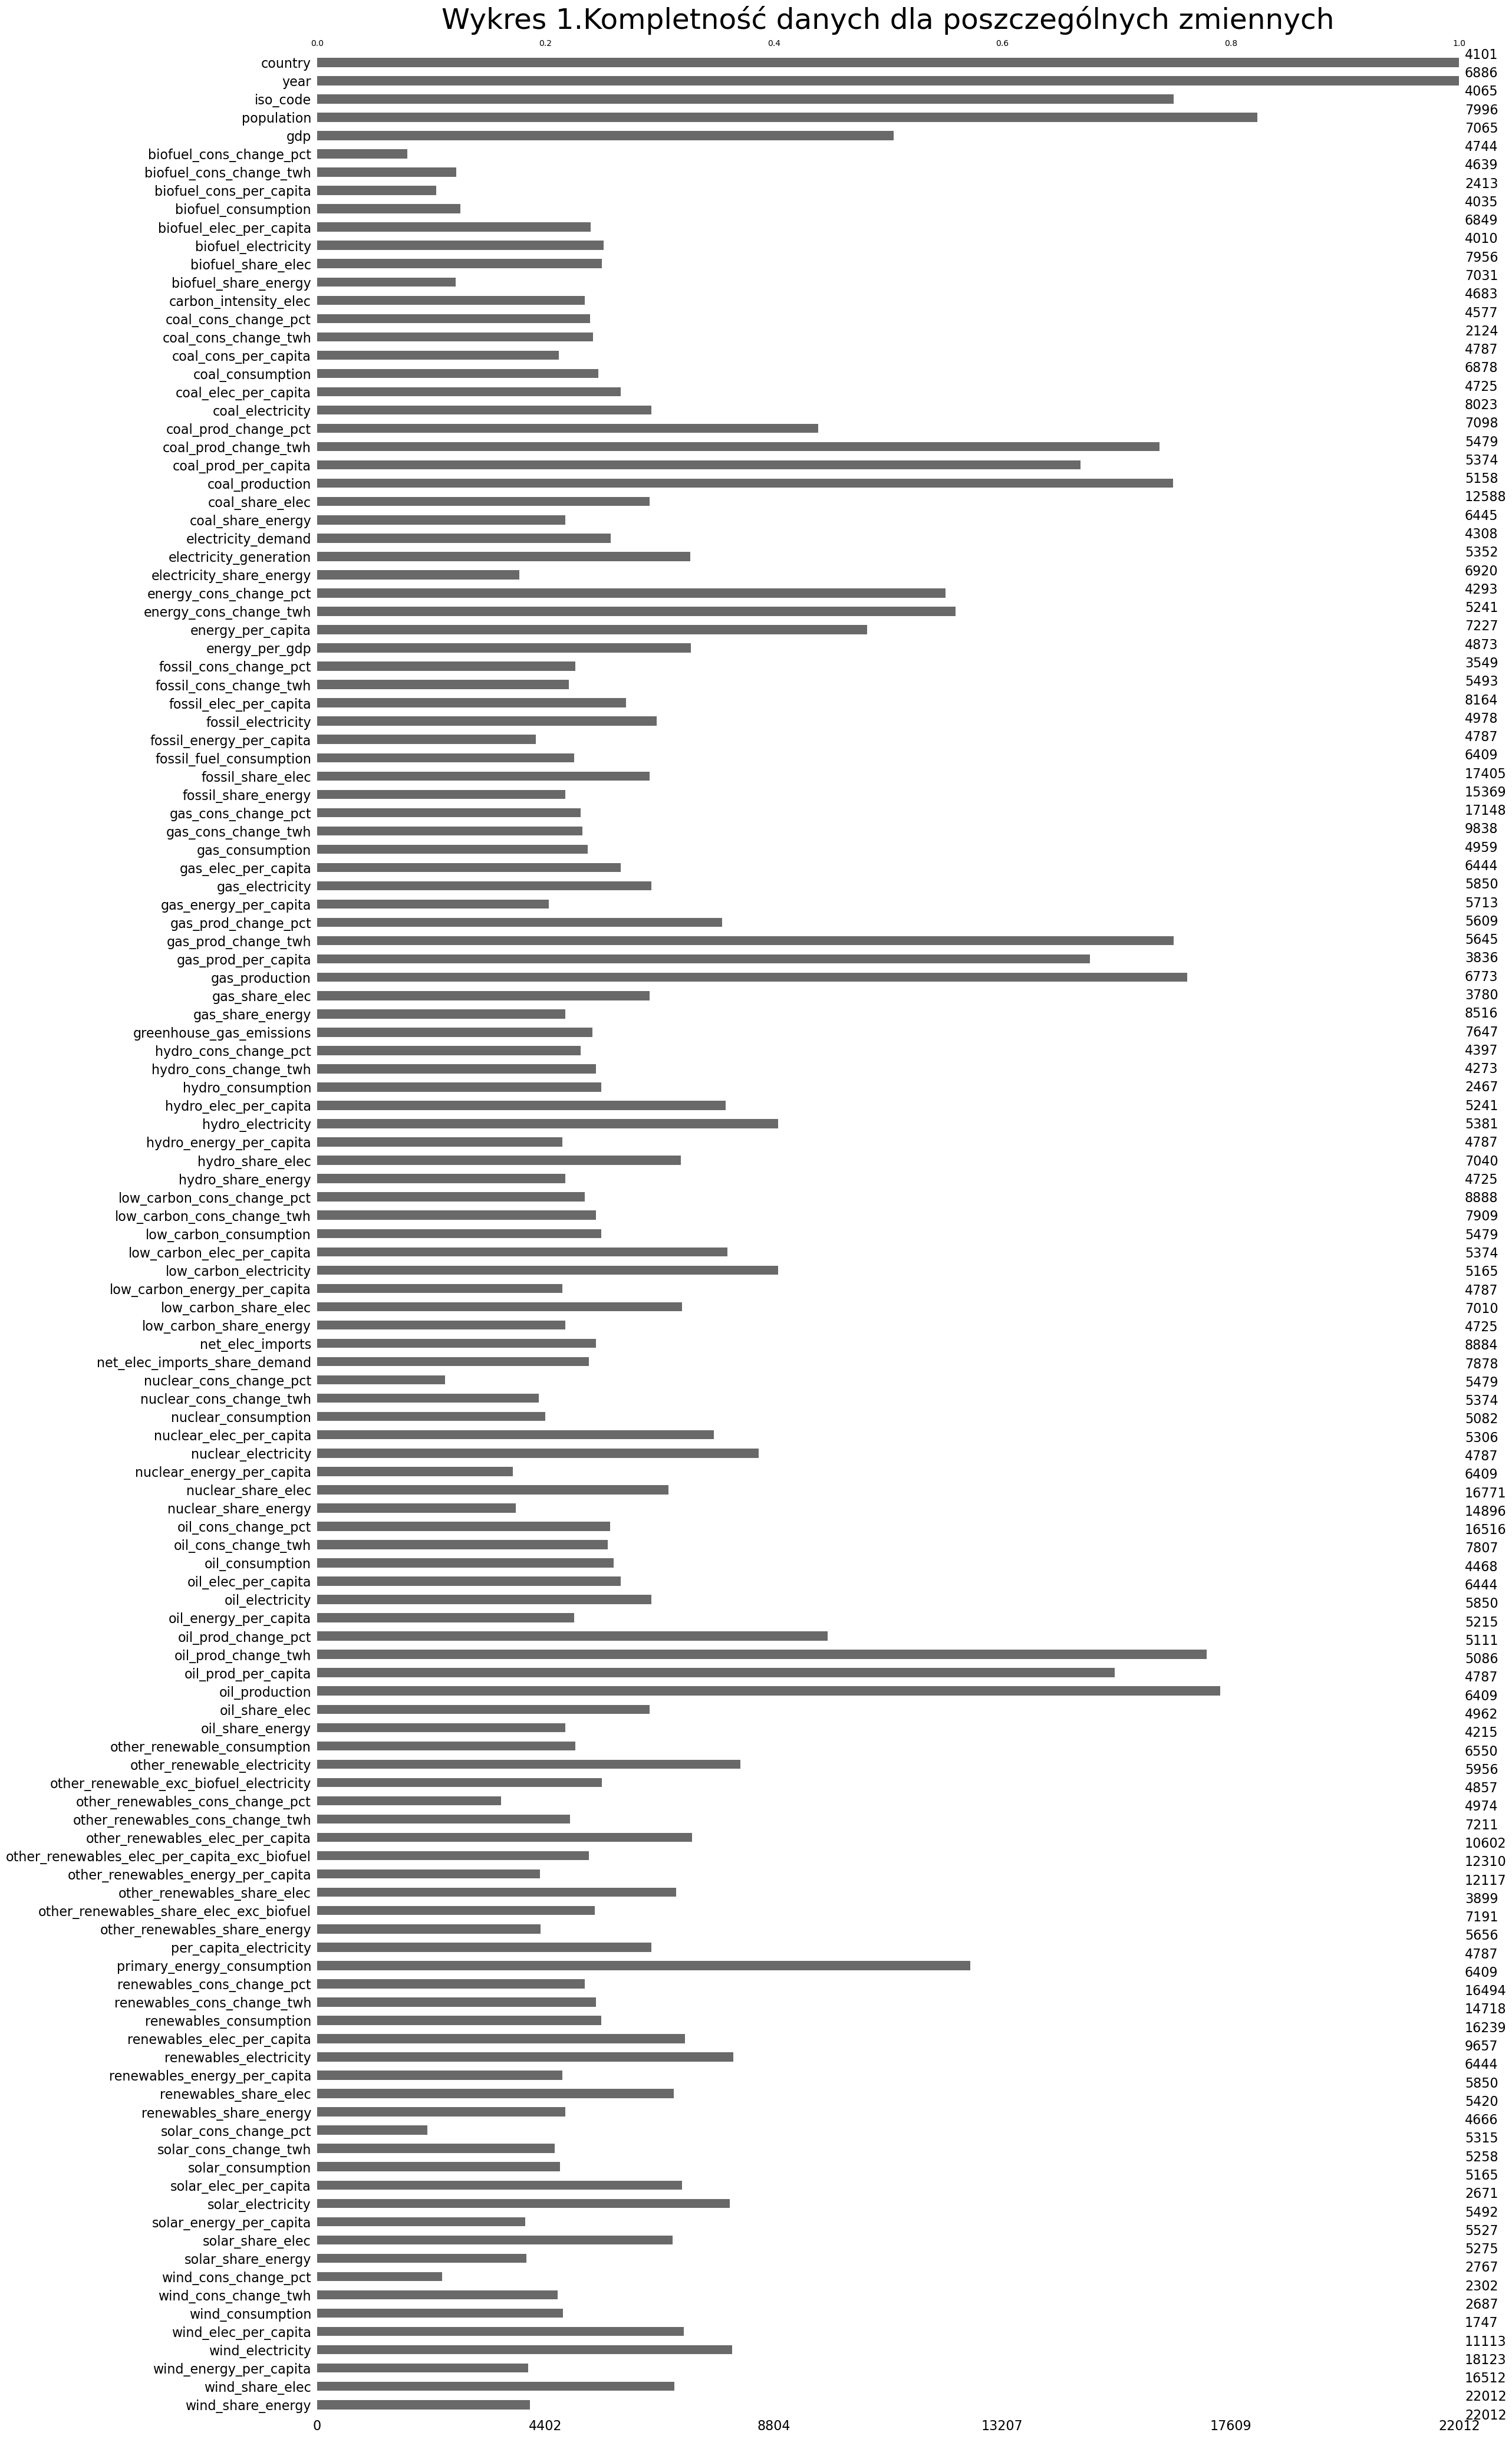

In [168]:
# ========================================================
#         Wizualizacja braków danych
# ========================================================

# Wykres 1: kompletność danych dla poszczególnych zmiennych

msno.bar(df)

plt.title(
    'Wykres 1.Kompletność danych dla poszczególnych zmiennych',
    fontsize=35,
    pad=30
)
plt.gca().invert_yaxis()
plt.show()

Wykres 1 przedstawia poziom kompletności danych dla poszczególnych zmiennych. Widoczne są różnice w liczbie dostępnych obserwacji pomiędzy zmiennymi. Zmienne o słupkach sięgających pełnej długości charakteryzują się kompletnymi lub niemal kompletnymi danymi, natomiast krótsze słupki wskazują na większy udział brakujących wartości.

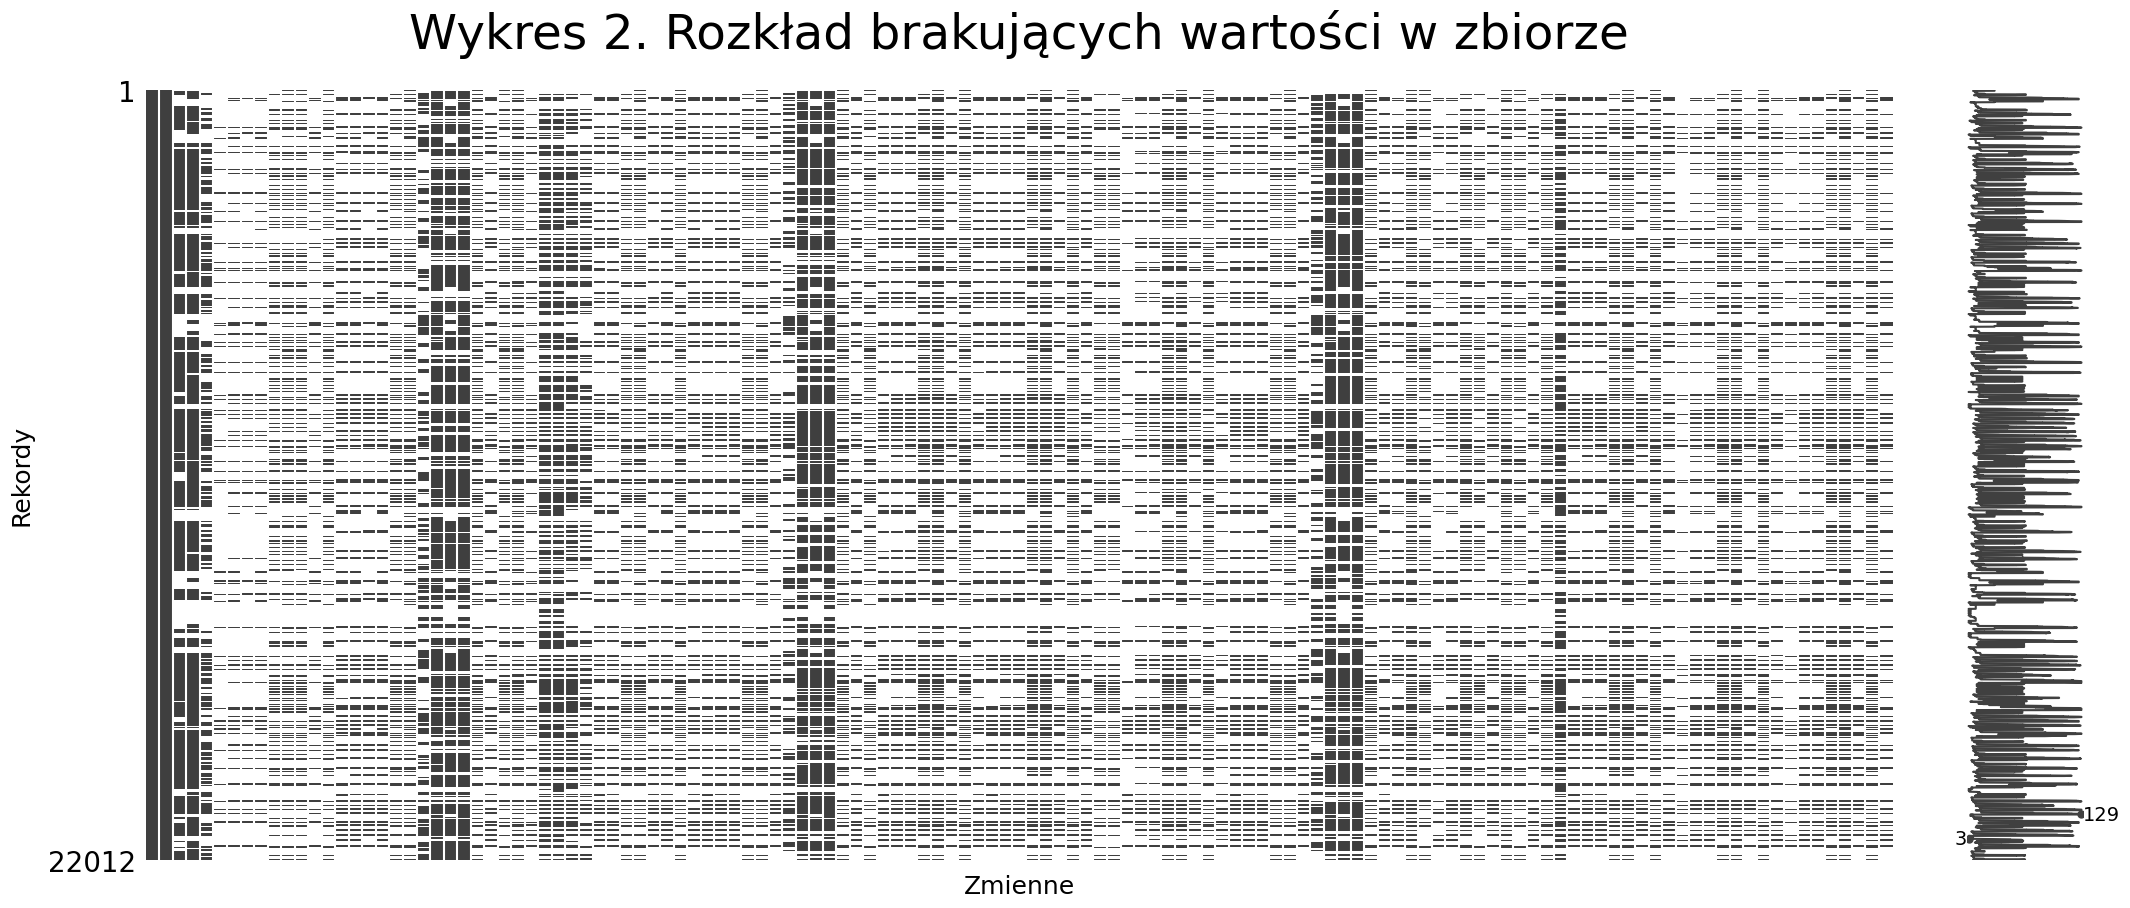

In [169]:
# Wykres 2: poglądowy wykres rozkładu brakujących wartości w zbiorze

msno.matrix(df)
plt.title(
    'Wykres 2. Rozkład brakujących wartości w zbiorze',
    fontsize=35,
    pad=30
)

plt.xlabel('Zmienne', fontsize=18, labelpad=10)
plt.ylabel('Rekordy', fontsize=18, labelpad=10)

plt.show()

Macierz braków zaprezentowana na Wykresie 2 przedstawia rozmieszczenie brakujących wartości w poszczególnych rekordach i zmiennych. Jasne pola oznaczają brakujące wartości, natomiast ciemne pola wskazują na wartości dostępne. Położenie poszczególnych pól umożliwia określenie, których rekordów oraz zmiennych dotyczą występujące braki.

Do Wykresu 2 można dodać informacje szczegółowe o numerze rekordu i nazwie zmiennej.

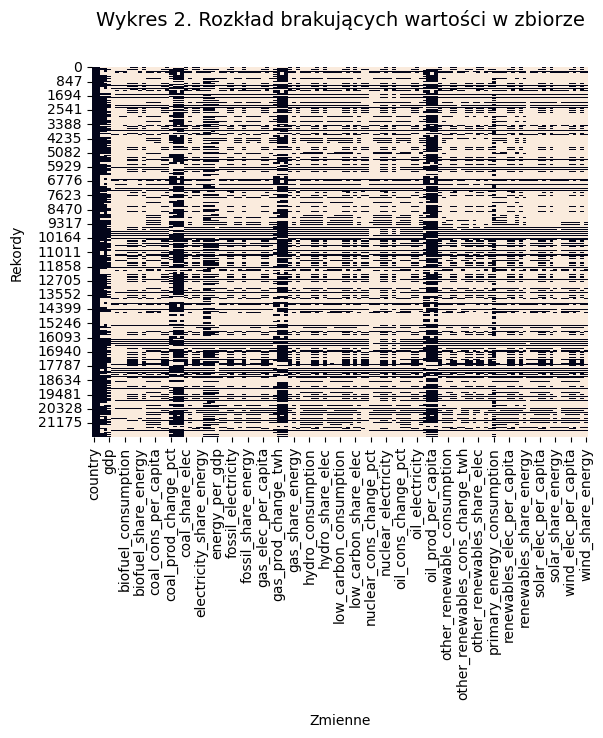

In [170]:
sns.heatmap(df.isna(), cbar=False)  

plt.title(
    'Wykres 2. Rozkład brakujących wartości w zbiorze',
    fontsize=14,
    pad=30
)

plt.xlabel('Zmienne', fontsize=10, labelpad=10)
plt.ylabel('Rekordy', fontsize=10, labelpad=10)

plt.show()

W kolejnym kroku przeanalizowano zróżnicowanie udziału brakujących wartości w poszczególnych zmiennych na przestrzeni badanego okresu.

/var/folders/c9/ygg1ptk506n7_w3bl2_7q5840000gn/T/ipykernel_64384/910697224.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year_var = df.groupby('year').apply(


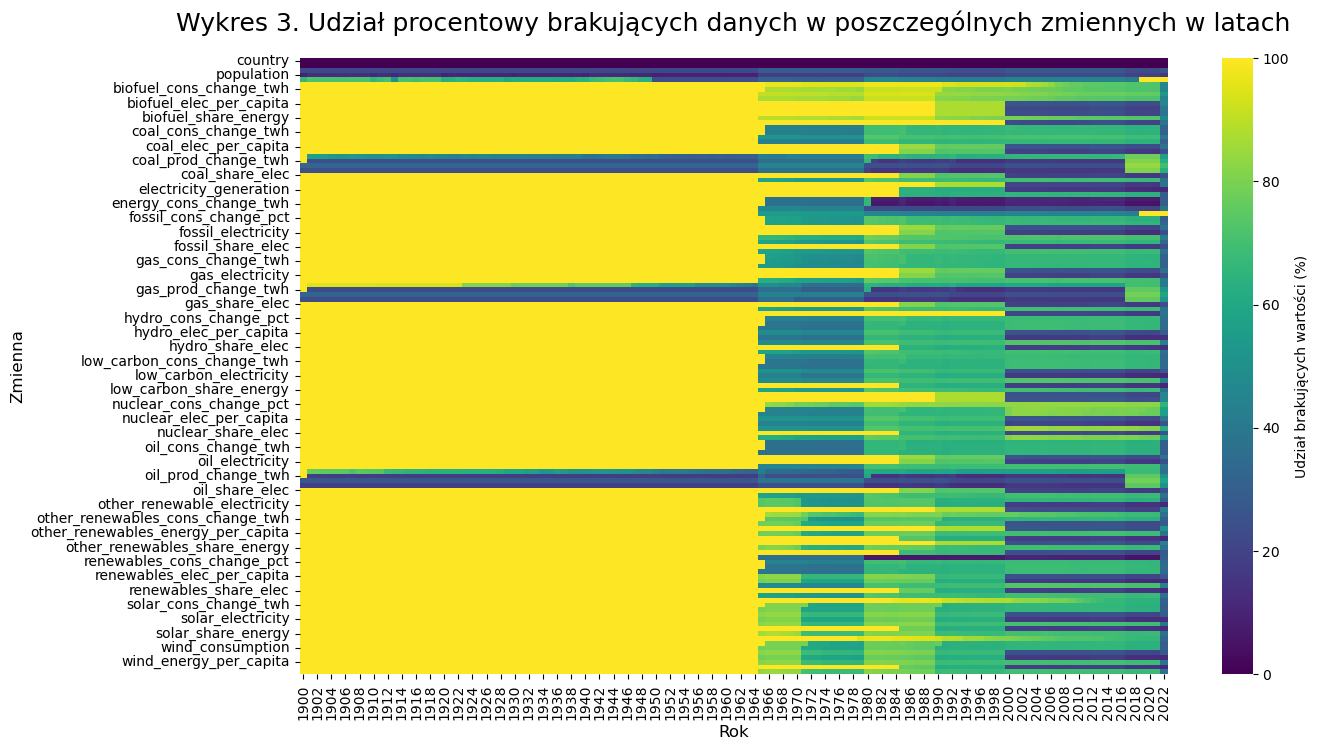

In [171]:
# Wykres 3. Udział brakujących danych w poszczególnych zmiennych w latach

missing_by_year_var = df.groupby('year').apply(
    lambda x: x.isna().mean() * 100
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    missing_by_year_var.T,
    cmap='viridis',
    cbar_kws={'label': 'Udział brakujących wartości (%)'}
)

plt.title(
    'Wykres 3. Udział procentowy brakujących danych w poszczególnych zmiennych w latach',
    fontsize=18,
    pad=20
)

plt.xlabel('Rok', fontsize=12)
plt.ylabel('Zmienna', fontsize=12)

plt.show()


Na wykresie 3 wyraźnie widoczna jest większa koncentracja brakujących wartości w starszych latach, podczas gdy dla nowszych okresów dane są na ogół bardziej kompletne. Jednocześnie poszczególne zmienne charakteryzują się zróżnicowanym poziomem dostępności danych.

W celu dokładniejszego określenia rozkładu brakujących wartości przeanalizowano dostępność danych dla wybranych zmiennych, istotnych z punktu widzenia dalszych etapów analizy. Szczególną uwagę poświęcono zmiennym dotyczącym produktu krajowego brutto, liczby ludności oraz zużycia energii pierwotnej.

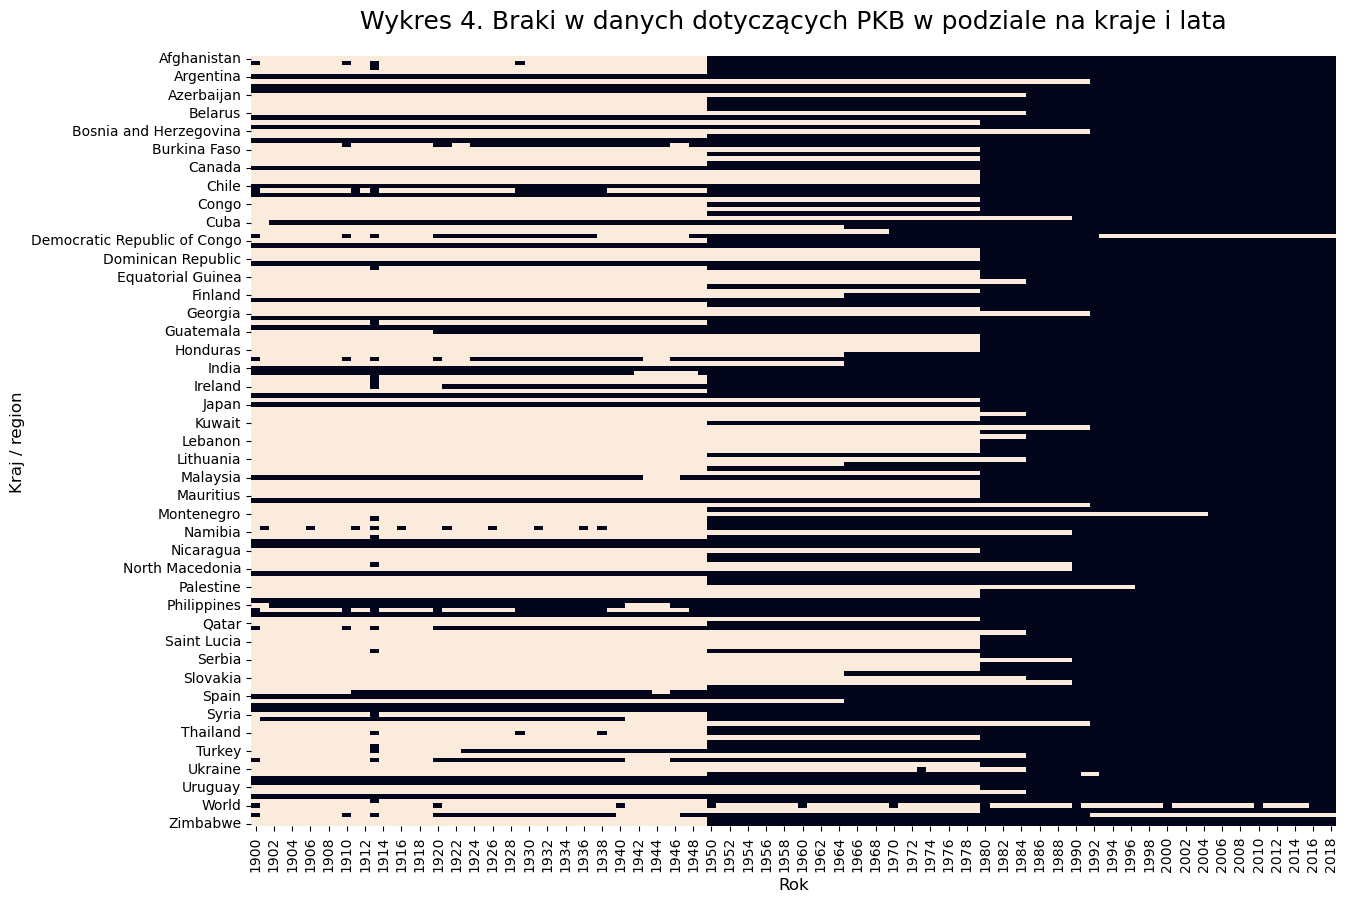

In [172]:
# Wykres 4: Macierz brakujących danych dotyczących PKB w podziale na kraje i lata

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.pivot_table(
        index='country',
        columns='year',
        values='gdp'
    ).isna(),
    cbar=False
)

plt.title(
    'Wykres 4. Braki w danych dotyczących PKB w podziale na kraje i lata',
    fontsize=18,
    pad=20
)

plt.xlabel('Rok', fontsize=12)
plt.ylabel('Kraj / region', fontsize=12)

plt.show()

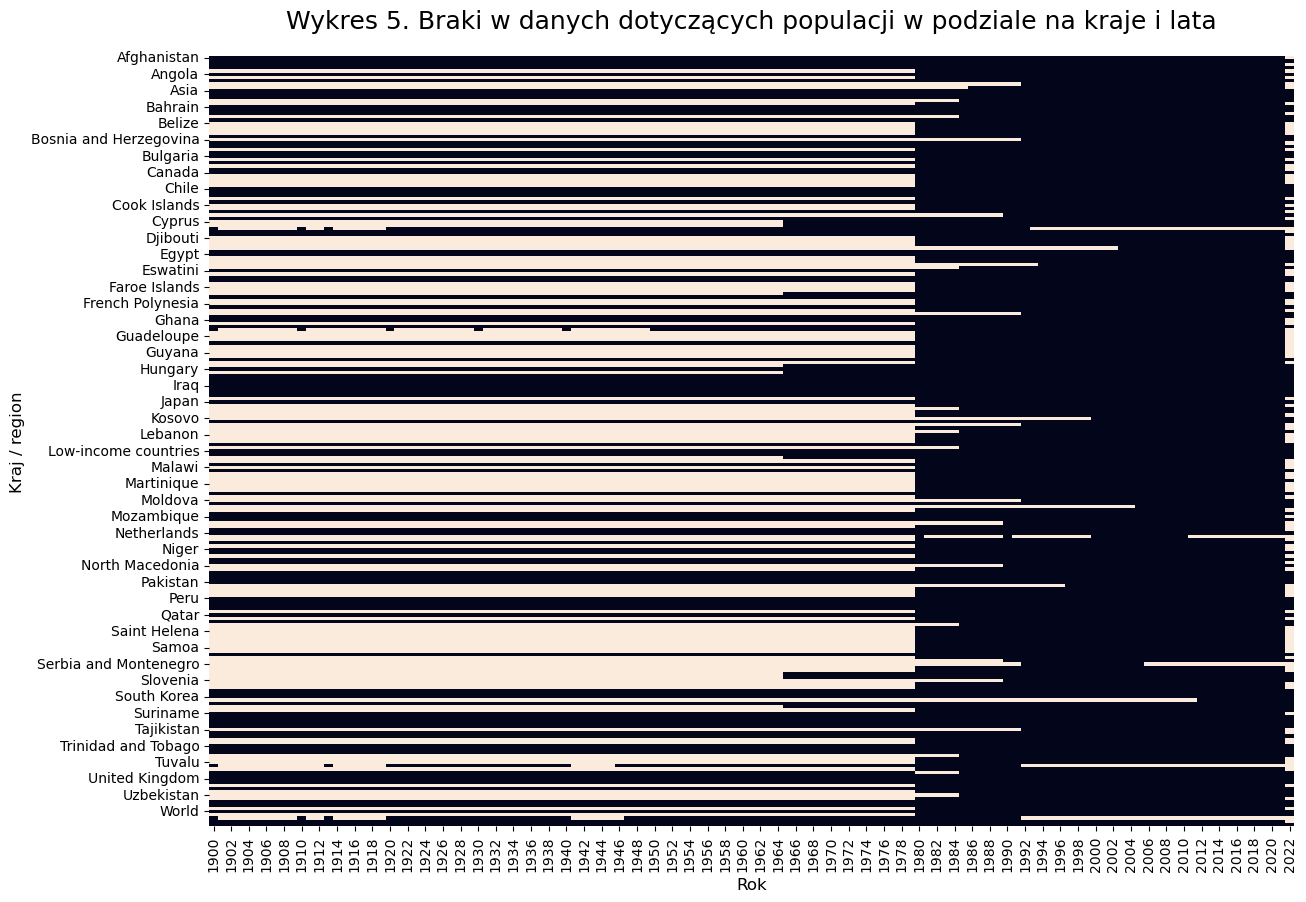

In [173]:
# Wykres 5: Macierz brakujących danych dotyczących populacji w podziale na kraje i lata

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.pivot_table(
        index='country',
        columns='year',
        values='population'
    ).isna(),
    cbar=False
)

plt.title(
    'Wykres 5. Braki w danych dotyczących populacji w podziale na kraje i lata',
    fontsize=18,
    pad=20
)

plt.xlabel('Rok', fontsize=12)
plt.ylabel('Kraj / region', fontsize=12)

plt.show()


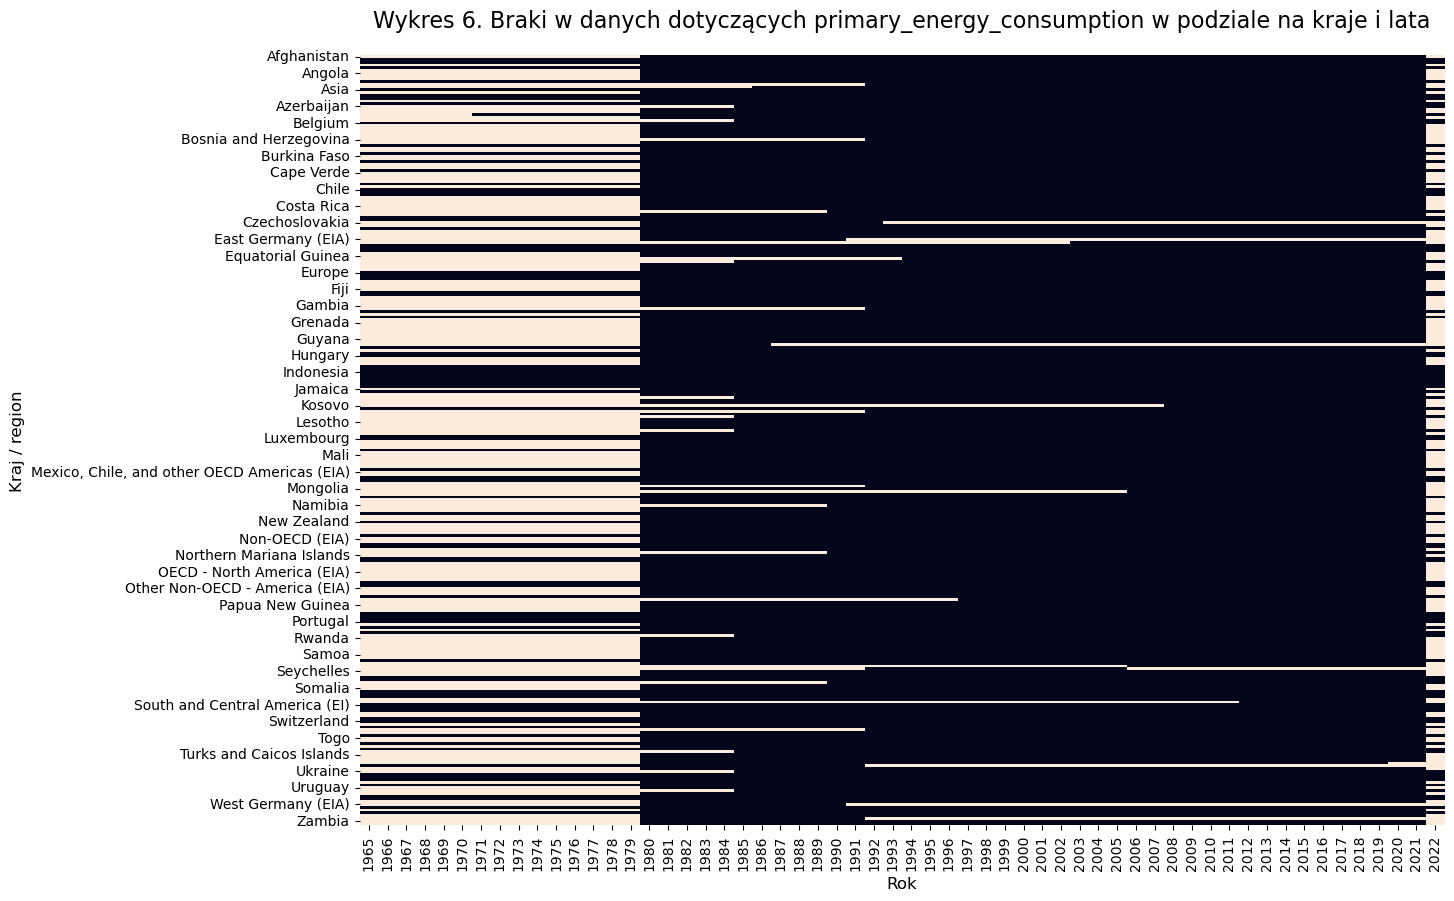

In [174]:
# Wykres 6: Macierz brakujących danych dotyczących zmiennej primary_energy_consumption w podziale na kraje i lata

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.pivot_table(
        index='country',
        columns='year',
        values='primary_energy_consumption'
    ).isna(),
    cbar=False
)

plt.title(
    'Wykres 6. Braki w danych dotyczących primary_energy_consumption w podziale na kraje i lata',
    fontsize=16,
    pad=20
)

plt.xlabel('Rok', fontsize=12)
plt.ylabel('Kraj / region', fontsize=12)

plt.show()

#### Wnioski:

Przeprowadzona analiza kompletności zbioru danych wykazała, że poziom dostępności informacji jest zróżnicowany w zależności od zmiennej, kraju oraz roku. W zbiorze występują braki danych, przy czym ich większa koncentracja widoczna jest w starszych latach badanego okresu. W nowszych latach dane są na ogół bardziej kompletne, co może wynikać z większej dostępności i systematyczności prowadzonych pomiarów oraz statystyk dotyczących energii, gospodarki i demografii.

Analiza poszczególnych zmiennych wykazała również, że stopień kompletności danych nie jest jednakowy. Różnice te są widoczne między innymi dla produktu krajowego brutto (gdp), liczby ludności (population) oraz zużycia energii pierwotnej (primary_energy_consumption). Dostępność danych różni się także pomiędzy poszczególnymi krajami i regionami, co należy uwzględnić podczas przeprowadzania dalszych analiz porównawczych.

Jednocześnie w analizowanym zbiorze nie stwierdzono zduplikowanych rekordów. Oznacza to, że przed rozpoczęciem właściwej analizy nie ma potrzeby przeprowadzania procesu usuwania duplikatów. Konieczne jest natomiast odpowiednie postępowanie z brakującymi wartościami.

W związku z powyższym w kolejnym etapie przeprowadzone zostanie przygotowanie i oczyszczenie danych. Obejmie ono przede wszystkim wybór danych istotnych z punktu widzenia prowadzonych analiz oraz określenie sposobu obsługi braków w danych, tak aby ograniczyć ich wpływ na wyniki końcowe.

## 4.  Przygotowanie i oczyszczenie danych

Dane OWID są wynikiem połączenia danych pochodzących z wielu źródeł (IEA, BP, GCP, World Bank), co powoduje występowanie różnic w dostępności danych dla poszczególnych krajów oraz lat. W przypadku niektórych zmiennych występują luki w danych wynikające z braku raportowania w latach historycznych. W związku z tym, przed przystąpieniem do właściwej analizy zużycia energii na świecie konieczne było przygotowanie i oczyszczenie pobranego zbioru danych.

Celem tego etapu było uzyskanie zbioru odpowiedniego do przeprowadzenia dalszych analiz, tak aby zapewnić ich spójność, kompletność oraz możliwość przeprowadzenia rzetelnych porównań. 

Proces przygotowania danych obejmował kilka etapów: selekcję obserwacji, obsługę braków danych, ograniczenie zakresu lat oraz przygotowanie zbioru do dalszych analiz eksploracyjnych i wizualizacji. Działania podjęte na tym etapie wynikały z charakterystyki zbioru oraz problemów zidentyfikowanych podczas wcześniejszego przeglądu jego kompletności.

Z racji tego, że w ramach projektu przedmiotem analiz są porównania między krajami, w pierwszej kolejności zweryfikowano wartości zmiennej "country", aby sprawdzić, jakie kraje znajdują się w zbiorze. 

In [175]:
# =================================================================================
#         Sprawdzenie liczby jednostek posiadających i nieposiadających kod ISO
# =================================================================================

print("Liczba wszystkich jednostek:", df['country'].nunique())

print("Liczba jednostek bez kodu ISO:", df.loc[df['iso_code'].isna(), 'country'].nunique())

Liczba wszystkich jednostek: 306
Liczba jednostek bez kodu ISO: 87


In [176]:
# wyświetlenie jednostek bez przypisanego kodu ISO

df.loc[df['iso_code'].isna(),'country'].drop_duplicates().sort_values().tolist()

['ASEAN (Ember)',
 'Africa',
 'Africa (EI)',
 'Africa (Ember)',
 'Africa (Shift)',
 'Asia',
 'Asia & Oceania (EIA)',
 'Asia (Ember)',
 'Asia Pacific (EI)',
 'Asia and Oceania (Shift)',
 'Australia and New Zealand (EIA)',
 'CIS (EI)',
 'Central & South America (EIA)',
 'Central America (EI)',
 'Central and South America (Shift)',
 'Czechoslovakia',
 'EU28 (Shift)',
 'East Germany (EIA)',
 'Eastern Africa (EI)',
 'Eurasia (EIA)',
 'Eurasia (Shift)',
 'Europe',
 'Europe (EI)',
 'Europe (Ember)',
 'Europe (Shift)',
 'European Union (27)',
 'European Union (EIA)',
 'G20 (Ember)',
 'G7 (Ember)',
 'Hawaiian Trade Zone (EIA)',
 'High-income countries',
 'IEO - Africa (EIA)',
 'IEO - Middle East (EIA)',
 'IEO OECD - Europe (EIA)',
 'Kosovo',
 'Latin America and Caribbean (Ember)',
 'Low-income countries',
 'Lower-middle-income countries',
 'Mexico, Chile, and other OECD Americas (EIA)',
 'Middle Africa (EI)',
 'Middle East (EI)',
 'Middle East (EIA)',
 'Middle East (Ember)',
 'Middle East (Shif

W zbiorze OWID oprócz państw znajdują się również agregaty geograficzne, takie jak World, Europe, Asia, czy ASEAN (Ember), OPEC. Jednostki te odnoszą się m.in. do kontynentów, regionów oraz grupy państw, czy innych organizacji. Nie są one porównywalne z pojedynczymi krajami, a ich obecność w rozpatrywanym zbiorze zaburzałaby analizy trendów, wielkości i porównań. 

W związku z tym do dalszego przetwarzania pozostawiono wyłącznie obserwacje, dla których dostępny jest kod kraju (iso_code). Usunięcie jednostek bez kodu ISO pozwoliło pominąć pozycje będące agregatami.

In [177]:
# ==============================================================================
#         Pominięcie danych niebędących przedmiotem analizy w ujęciu krajów
# ==============================================================================

# utworzenie zbioru zawierającego wyłącznie jednostki z kodem ISO, będące przedmiotem analizy (kraje, nie regiony)
df_2 = df[df['iso_code'].notna()].copy()

# wyświetlenie liczby krajów w zbiorze danych po odfiltrowaniu jednostek niebędących przedmiotem analizy (regiony, itp.)
print("Liczba krajów:", df_2['country'].nunique())

# sprawdzenie, czy dane zostały poprawnie przefiltrowane (zestawienie poglądowe)
df_2.country.unique().tolist()

Liczba krajów: 219


['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Angola',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czechia',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Falkland Islands',
 'Faroe Islands',
 'Fiji',
 'Finland',
 'France',
 'F

Po analizie pozostałych obserwacji stwierdzono, że w zbiorze nadal występują terytoria zależne różnych państw i inne jednostki, które posiadają własne kody ISO. W celu ich wyeliminowania z dalszej analizy przygotowano dodatkową listę obejmującą te jednostki, a następnie usunięto odpowiadające im obserwacje ze zbioru danych.

Pozwoliło to wykluczyć z analizy m.in. Hongkong, Portoryko oraz Grenlandię, czy też Antarktykę dzięki czemu nie są one uwzględniane w rankingach i porównaniach prowadzonych dla poszczególnych państw.

W rezultacie utworzono ostateczny zbiór df_2, który obejmuje kraje przeznaczone do dalszej analizy. Zbiór ten stanowi podstawę kolejnych analiz dotyczących zużycia energii na poziomie państw.

In [178]:
#================================================================================
#         Lista terytoriów zależnych i innych jednostek niebędących państwami
#================================================================================

territories = [
    'American Samoa',
    'Antarctica',
    'Aruba',
    'Bermuda',
    'British Virgin Islands',
    'Cayman Islands',
    'Falkland Islands',
    'Faroe Islands',
    'French Guiana',
    'French Polynesia',
    'Gibraltar',
    'Greenland',
    'Guadeloupe',
    'Guam',
    'Hong Kong',
    'Macao',
    'Martinique',
    'Montserrat',
    'Netherlands Antilles',
    'New Caledonia',
    'Northern Mariana Islands',
    'Puerto Rico',
    'Reunion',
    'Saint Helena',
    'Saint Pierre and Miquelon',
    'Turks and Caicos Islands',
    'United States Virgin Islands'
]

# zawężenie zbioru df_2 
df_2 = df_2[~df_2['country'].isin(territories)].copy()

# wyświetlenie liczby krajów w zbiorze danych po odfiltrowaniu 
print("Liczba krajów po odfiltrowaniu:", df_2['country'].nunique())

Liczba krajów po odfiltrowaniu: 192


Ze względu na występowanie wartości brakujących w zbiorze danych w kolejnym kroku dokonano wyliczenia udziału procentowego braków w danych historycznych dla każdego okresu dostępnego w źródle.

In [179]:
# udział brakujących danych dla lat dostępnych w zbiorze

missing_pct_year = df_2.groupby('year').apply(lambda x: x.isna().mean().mean() * 100)
missing_pct_year = missing_pct_year.round(2).astype(str) + '%'
missing_pct_year

/var/folders/c9/ygg1ptk506n7_w3bl2_7q5840000gn/T/ipykernel_64384/1594234182.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_pct_year = df_2.groupby('year').apply(lambda x: x.isna().mean().mean() * 100)


year
1900     93.2%
1901    91.17%
1902    91.16%
1903    91.15%
1904    91.13%
         ...  
2018    38.19%
2019    39.45%
2020    39.49%
2021    39.48%
2022    31.89%
Length: 123, dtype: object

W zbiorze występują lata, które mają ponad 60–94% braków w zmiennych. Okresy ze zmiennymi o tak niskiej dostępności danych:

* nie nadają się do analizy trendów,
* utrudniają wizualizacje,
* mogą prowadzić do błędnych interpretacji.

Na potrzeby oceny, jak skrócenie szeregu czasowego wpłynie na kompletność danych, przeanalizowano poziom braków dla pięciu wybranych przedziałów czasowych.

In [180]:
# obliczenie procentu brakujących wartości w analizowanych przedziałach czasowych

periods = {
    "1900–2022": (1900, 2022), # pełny szereg czasowy dostępny w zbiorze
    "1950–2022": (1950, 2022),
    "1980–2022": (1980, 2022),
    "1990–2022": (1990, 2022),
    "2000–2022": (2000, 2022)
}

results = []

for name, (start, end) in periods.items():
    temp = df_2[(df_2["year"] >= start) & (df_2["year"] <= end)]
    
    results.append({
        "okres": name,
        "liczba_obserwacji": len(temp),
        "procent_braków": temp.isna().mean().mean() * 100
    })

comparison = pd.DataFrame(results)
print(comparison)

       okres  liczba_obserwacji  procent_braków
0  1900–2022              15288       65.258662
1  1950–2022              10738       54.382538
2  1980–2022               7888       46.334831
3  1990–2022               6178       40.913369
4  2000–2022               4311       34.318734


Powyższe zestawienie wskazuje, że wraz ze skracaniem szeregu czasowego poprzez pominięcie najstarszych obserwacji zmniejsza się udział brakujących danych. Oznacza to, że początkowe lata analizowanego szeregu charakteryzują się większą liczbą braków, co może negatywnie wpływać na jakość analiz prowadzonych dla pełnego okresu 1900–2022. Jednocześnie ograniczenie zakresu czasowego prowadzi do zmniejszenia liczby dostępnych obserwacji.

Aby zwiększyć jakość analizy, ograniczono zakres lat do przedziału 2000–2022, co pozwala skupić się na okresie dynamicznych zmian w sektorze energetycznym oraz uniknąć problemów związanych z niekompletnością danych historycznych.  W rezultacie otrzymano bardziej kompletny i porównywalny zbiór danych, odpowiedni do przeprowadzenia dalszej analizy eksploracyjnej.

In [181]:
# ========================================================================
#         Pominięcie rekordów z lat historycznych
# ========================================================================

# wyfiltrowanie danych dla okresów po roku 1999
df_2 = df_2[df_2['year'] >= 2000]

# sprawdzenie minimalnej wartości w kolumnie 'year' po usunięciu rekordów z lat historycznych
print("Minimalny rok w zbiorze danych po filtrowaniu:", df_2['year'].min())

# podgląd danych po usunięciu rekordów z lat historycznych
df_2.head()

Minimalny rok w zbiorze danych po filtrowaniu: 2000


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
123,Afghanistan,2000,AFG,19542986.0,1.128379e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
124,Afghanistan,2001,AFG,19688634.0,1.102127e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
125,Afghanistan,2002,AFG,21000258.0,1.880487e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
126,Afghanistan,2003,AFG,22645136.0,2.107434e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
127,Afghanistan,2004,AFG,23553554.0,2.233257e+10,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN


Dalej przeanalizowano zmienne znajdujące się w nowo utworzonym zbiorze danych pod kątem występowania brakujących wartości.

In [182]:
# ========================================================================
#         Analiza braków danych dla zmiennych w zbiorze 
# ========================================================================

# obliczenie udziału brakujących wartości w każdej zmiennej
missing_pct = df_2.isna().mean()

# wyświetlenie udziału brakujących wartości w każdej zmiennej
print("Udział brakujących wartości w każdej zmiennej:")
print(missing_pct.round(4).sort_values(ascending=False))

Udział brakujących wartości w każdej zmiennej:
nuclear_cons_change_pct      0.8395
nuclear_cons_change_twh      0.8028
nuclear_share_energy         0.8010
nuclear_energy_per_capita    0.7987
nuclear_consumption          0.7987
                              ...  
energy_per_capita            0.0084
population                   0.0000
iso_code                     0.0000
year                         0.0000
country                      0.0000
Length: 129, dtype: float64


Przyjęto próg 60% braków, powyżej którego zmienną należałoby usunąć ze zbioru do dalszej analizy.

In [183]:
# ========================================================================
#         Pominięcie zmiennych z nadmierną liczbą braków danych (>60%)
# ========================================================================

# ustalenie progu braków danych, powyżej którego zmienne zostaną pominięte w dalszej analizie
threshold = 0.60

# identyfikacja zmiennych, które przekraczają przyjęty próg
removed_cols = missing_pct[missing_pct > threshold]

print("\nZmienne do usunięcia:")

if removed_cols.empty:
    print("Brak zmiennych przekraczających ustalony próg braków.")
else:
    print((removed_cols * 100).round(2).sort_values(ascending=False))
    df_3 = df_2.drop(columns=removed_cols.index)


Zmienne do usunięcia:
nuclear_cons_change_pct             83.95
nuclear_cons_change_twh             80.28
nuclear_share_energy                80.10
nuclear_consumption                 79.87
nuclear_energy_per_capita           79.87
biofuel_cons_change_pct             77.57
biofuel_share_energy                72.81
biofuel_cons_change_twh             72.47
biofuel_cons_per_capita             72.00
biofuel_consumption                 72.00
solar_cons_change_pct               70.63
wind_cons_change_pct                68.62
other_renewables_cons_change_pct    68.01
coal_prod_change_pct                67.20
solar_share_energy                  64.65
renewables_share_energy             64.37
oil_share_energy                    64.37
other_renewables_share_energy       64.37
low_carbon_share_energy             64.37
wind_share_energy                   64.37
coal_share_energy                   64.37
hydro_share_energy                  64.37
gas_share_energy                    64.37
fossil_shar

In [184]:
#zliczenie liczby usuniętych zmiennych 
print("Liczba usuniętych zmiennych: ", removed_cols.count())

Liczba usuniętych zmiennych:  40


In [185]:
# wyświetlenie listy zmiennych pozostałych w zbiorze danych po usunięciu zmiennych z nadmierną liczbą braków danych
print("Zmienne pozostałe w zbiorze danych:")
df_3.columns.tolist()

Zmienne pozostałe w zbiorze danych:


['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'biofuel_elec_per_capita',
 'biofuel_electricity',
 'biofuel_share_elec',
 'carbon_intensity_elec',
 'coal_cons_change_twh',
 'coal_cons_per_capita',
 'coal_consumption',
 'coal_elec_per_capita',
 'coal_electricity',
 'coal_prod_change_twh',
 'coal_prod_per_capita',
 'coal_production',
 'coal_share_elec',
 'electricity_demand',
 'electricity_generation',
 'electricity_share_energy',
 'energy_cons_change_pct',
 'energy_cons_change_twh',
 'energy_per_capita',
 'energy_per_gdp',
 'fossil_cons_change_pct',
 'fossil_elec_per_capita',
 'fossil_electricity',
 'fossil_share_elec',
 'gas_cons_change_pct',
 'gas_cons_change_twh',
 'gas_consumption',
 'gas_elec_per_capita',
 'gas_electricity',
 'gas_energy_per_capita',
 'gas_prod_change_pct',
 'gas_prod_change_twh',
 'gas_prod_per_capita',
 'gas_production',
 'gas_share_elec',
 'greenhouse_gas_emissions',
 'hydro_elec_per_capita',
 'hydro_electricity',
 'hydro_share_elec',
 'low_carbon_ele

Na podstawie wyników zwróconych w poprzednim kroku, z pierwotnego zbioru danych usunięte zostało 40 zmiennych, które w analizowanym okresie 2000-2022 miały braki w danych przekroczające zakładany próg 60%. 

Po usunięciu zmiennych z nadmierną liczbą braków danych, zbiór danych (oznaczony df_3) został zredukowany do 89 zmiennych, które będą podlegały dalszej analizie.

In [186]:
# wielkość zbioru po usunięciu kolumn z nadmierną liczbą braków danych
df_3.shape

(4311, 89)

In [187]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4311 entries, 123 to 22011
Data columns (total 89 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   country                                       4311 non-null   object 
 1   year                                          4311 non-null   int64  
 2   iso_code                                      4311 non-null   object 
 3   population                                    4311 non-null   float64
 4   gdp                                           3092 non-null   float64
 5   biofuel_elec_per_capita                       4215 non-null   float64
 6   biofuel_electricity                           4215 non-null   float64
 7   biofuel_share_elec                            4180 non-null   float64
 8   carbon_intensity_elec                         4203 non-null   float64
 9   coal_cons_change_twh                          1734 non-null   flo

#### Imputacja brakujących wartości

Po wstępnej selekcji w zbiorze nadal występowały braki w wielu zmiennych liczbowych, szczególnie w populacji, PKB oraz wybranych wskaźnikach energetycznych.

In [188]:
# Sprawdzenie liczby brakujących wartości w każdej kolumnie 
# po usunięciu zmiennych z nadmierną liczbą braków danych oraz zawężeniu danych do lat 2000-2022

df_3.isna().sum()


country                      0
year                         0
iso_code                     0
population                   0
gdp                       1219
                          ... 
wind_consumption          2517
wind_elec_per_capita        58
wind_electricity            58
wind_energy_per_capita    2517
wind_share_elec             93
Length: 89, dtype: int64

Aby zachować ciągłość czasową i umożliwić analizę trendów, dla uzupełnienia braków w zmiennych numerycznych zastosowano interpolację liniową.

Zastosowano interpolację liniową, ponieważ Pandas domyślnie używa metody linear, która jest najbardziej odpowiednia dla danych czasowych. Wartości energetyczne zmieniają się stopniowo w czasie, a braki w danych OWID są zwykle pojedyncze lub krótkie. Interpolacja liniowa zachowuje trend między latami, nie wprowadza sztucznych skoków i jest stabilna w analizie.

Interpolacja została wykonana osobno dla każdego kraju, aby zachować ciągłość czasową w obrębie serii.

In [189]:
# ==============================================================================
#         Interpolacja liniowa brakujących wartości w poszczególnych krajach
# ==============================================================================

# wybór kolumn numerycznych
num_cols = df_3.select_dtypes(include=['float64', 'int64']).columns

# sortowanie według kraju i roku
# df_3 = df_3.sort_values(["country", "year"])

# interpolacja po krajach z zachowaniem indeksu
df_3[num_cols] = df_3.groupby('country')[num_cols].transform(lambda x: x.interpolate())


Po przeprowadzeniu interpolacji ponownie sprawdzono liczbę brakujących wartości w poszczególnych zmiennych. Pozwoliło to zweryfikować skuteczność zastosowanej metody oraz zidentyfikować braki, których nie udało się uzupełnić.

In [190]:
# sprawdzenie, czy w kolumnach numerycznych po interpolacji nadal występują braki danych 
df_3[num_cols].isna().sum()

year                          0
population                    0
gdp                         626
biofuel_elec_per_capita      67
biofuel_electricity          67
                           ... 
wind_consumption           2517
wind_elec_per_capita         44
wind_electricity             44
wind_energy_per_capita     2517
wind_share_elec              67
Length: 87, dtype: int64

***Braki nadal są - zastosować jakąś inna metodę imputacji?***

In [191]:
# określenie ile braków jest w wybranych kolumnach po interpolacji
missing_gdp = df_3['gdp'].isna().sum()
missing_population = df_3['population'].isna().sum()
missing_primary_energy_consumption = df_3['primary_energy_consumption'].isna().sum()
missing_energy_per_capita = df_3['energy_per_capita'].isna().sum()

print(f"Braki w kolumnie 'gdp': {missing_gdp}")
print(f"Braki w kolumnie 'population': {missing_population}")
print(f"Braki w kolumnie 'primary_energy_consumption': {missing_primary_energy_consumption}")
print(f"Braki w kolumnie 'energy_per_capita': {missing_energy_per_capita}")

Braki w kolumnie 'gdp': 626
Braki w kolumnie 'population': 0
Braki w kolumnie 'primary_energy_consumption': 7
Braki w kolumnie 'energy_per_capita': 7


W wyniku przeprowadzonych operacji utworzony został finalny zbiór analityczny df_3, który będzie stanowił podstawę dalszych analiz statystycznych i porównawczych.

## 5. Eksploracyjna analiza danych (EDA)

Po zakończeniu procesu czyszczenia danych przeprowadzono analizę eksploracyjną nowo utworzonego zbioru danych. Jej celem było poznanie struktury przygotowanego zbioru, analiza podstawowych statystyk oraz identyfikacja najważniejszych trendów i zależności dotyczących zużycia energii.

In [192]:
# ========================================================================
#         Podstawowe informacje o zbiorze po czyszczeniu
# ========================================================================

print("Liczba obserwacji:", df_3.shape[0])
print("Liczba zmiennych:", df_3.shape[1])
print("Liczba krajów i jednostek:", df_3['country'].nunique())
print("Zakres lat:", df_3['year'].min(), "-", df_3['year'].max())


Liczba obserwacji: 4311
Liczba zmiennych: 89
Liczba krajów i jednostek: 192
Zakres lat: 2000 - 2022


In [193]:
# sprawdzenie struktury zbioru danych, liczby obserwacji, typów zmiennych oraz liczby wartości niepustych
df_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4311 entries, 123 to 22011
Data columns (total 89 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   country                                       4311 non-null   object 
 1   year                                          4311 non-null   int64  
 2   iso_code                                      4311 non-null   object 
 3   population                                    4311 non-null   float64
 4   gdp                                           3685 non-null   float64
 5   biofuel_elec_per_capita                       4244 non-null   float64
 6   biofuel_electricity                           4244 non-null   float64
 7   biofuel_share_elec                            4221 non-null   float64
 8   carbon_intensity_elec                         4244 non-null   float64
 9   coal_cons_change_twh                          1737 non-null   flo

In [194]:
# sprawdzenie liczby brakujących wartości w poszczególnych kolumnach
df_3.isna().sum()

country                      0
year                         0
iso_code                     0
population                   0
gdp                        626
                          ... 
wind_consumption          2517
wind_elec_per_capita        44
wind_electricity            44
wind_energy_per_capita    2517
wind_share_elec             67
Length: 89, dtype: int64

W celu lepszego poznania struktury danych przeprowadzono analizę podstawowych statystyk opisowych dla zmiennych numerycznych. Pozwala ona określić zakres wartości, wartości średnie, mediany oraz zróżnicowanie analizowanych cech.

In [195]:
# Statystyki opisowe zmiennych numerycznych
df_3.describe().T

,count,mean,std,min,25%,50%,75%,max
year,4311.0,2.010816e+03,6.509849e+00,2000.0,2.005000e+03,2.011000e+03,2.016000e+03,2.022000e+03
population,4311.0,3.739759e+07,1.389324e+08,1833.0,2.073161e+06,8.120105e+06,2.557688e+07,1.425894e+09
gdp,3685.0,5.671277e+11,1.812039e+12,312853568.0,2.329941e+10,7.706383e+10,3.707453e+11,1.815162e+13
biofuel_elec_per_capita,4244.0,6.560039e+01,2.053804e+02,0.0,0.000000e+00,2.775000e-01,3.183425e+01,2.514102e+03
biofuel_electricity,4244.0,1.980978e+00,8.382308e+00,0.0,0.000000e+00,1.000000e-02,3.800000e-01,1.721300e+02
...,...,...,...,...,...,...,...,...
wind_consumption,1794.0,2.215758e+01,1.050109e+02,0.0,3.000000e-03,3.835000e-01,6.782000e+00,1.988450e+03
wind_elec_per_capita,4267.0,7.768037e+01,2.695787e+02,0.0,0.000000e+00,0.000000e+00,1.251050e+01,3.219852e+03
wind_electricity,4267.0,3.519034e+00,2.633304e+01,0.0,0.000000e+00,0.000000e+00,1.200000e-01,8.005200e+02
wind_energy_per_capita,1794.0,4.528703e+02,1.026019e+03,0.0,8.550000e-02,2.408950e+01,3.516860e+02,8.422012e+03


## 6. Analiza produkcji energii elektrycznej

##### 6.1 Produkcja energii elektrycznej na świecie

Do porównania produkcji energii elektrycznej wykorzystano zmienną electricity_generation, która przedstawia całkowitą ilość energii elektrycznej wytworzonej w danym kraju lub regionie, wyrażoną w terawatogodzinach (TWh). 

Analizę przeprowadzono dla sześciu wybranych kontynentów, wykorzystując wartości z 2000 oraz 2022 roku. Takie zestawienie pozwala określić zarówno zmianę poziomu produkcji energii elektrycznej, jak i tempo tej zmiany w poszczególnych częściach świata. Podobnie jak w przypadku analizy zużycia energii pierwotnej, obliczono zmianę w wartościach bezwzględnych oraz procentową pomiędzy analizowanymi latami.

In [196]:
# utworzenie zbioru danych do analiz dla kontynentów

continents = [
    'Africa',
    'Asia',
    'Europe',
    'North America',
    'South America',
    'Oceania'
]

df_continents = df[df['country'].isin(continents)]
df_continents = df_continents[df_continents['year'] >= 2000]
df_continents

# Porównanie produkcji energii elektrycznej w 2000 i 2022 roku

electricity_comparison = (
    df_continents[
        df_continents['year'].isin([2000, 2022])
    ]
    .pivot(
        index='country',
        columns='year',
        values='electricity_generation'
    )
)

# Zmiana produkcji energii elektrycznej
electricity_comparison['change'] = (
    electricity_comparison[2022]
    - electricity_comparison[2000]
)

# Procentowa zmiana produkcji energii elektrycznej
electricity_comparison['change_in_%'] = (
    (electricity_comparison[2022] - electricity_comparison[2000])
    / electricity_comparison[2000]
    * 100
)

# Zaokrąglenie wyników
electricity_comparison = electricity_comparison.round(2)

# Wyświetlenie wyników w kolejności od największej do najmniejszej zmiany procentowej
electricity_comparison = electricity_comparison.sort_values('change_in_%', ascending=False)

electricity_comparison


year,2000,2022,change,change_in_%
country,,,,
Asia,4637.52,16214.56,11577.04,249.64
Africa,420.55,892.73,472.18,112.28
South America,689.00,1256.98,567.98,82.44
Oceania,243.35,318.24,74.89,30.78
North America,4676.00,5638.28,962.28,20.58
Europe,4305.37,4781.19,475.82,11.05


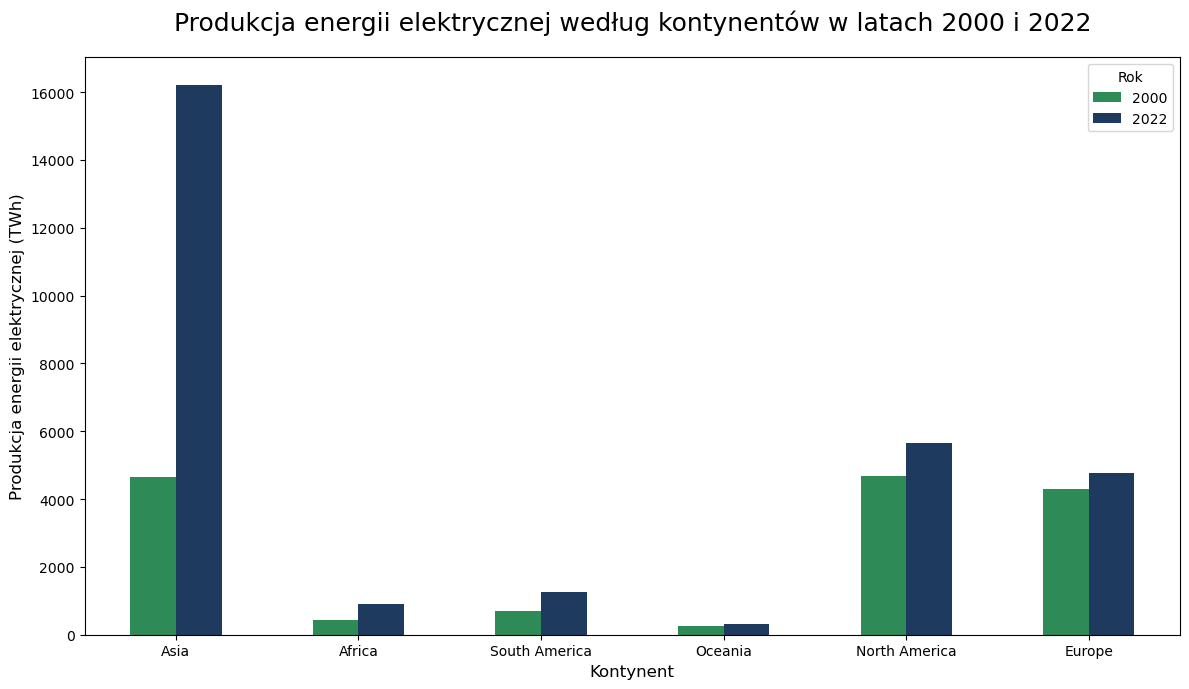

In [197]:
# Wykres: Produkcja energii elektrycznej według kontynentów – 2000 i 2022

electricity_comparison[[2000, 2022]].plot(
    kind='bar',
    figsize=(12, 7),
    color=['#2E8B57', '#1F3A5F']
)

plt.title(
    'Produkcja energii elektrycznej według kontynentów w latach 2000 i 2022',
    fontsize=18,
    pad=20
)

plt.xlabel('Kontynent', fontsize=12)
plt.ylabel('Produkcja energii elektrycznej (TWh)', fontsize=12)

plt.xticks(rotation=0)
plt.legend(title='Rok')

plt.tight_layout()
plt.show()


Analiza produkcji energii elektrycznej wskazuje na zróżnicowanie jej poziomu pomiędzy poszczególnymi kontynentami. W 2022 r. największą produkcją charakteryzowała się Azja, natomiast najmniejszą wartość odnotowano dla Oceanii. W porównaniu z 2000 r. produkcja energii elektrycznej wzrosła na wszystkich analizowanych kontynentach.

Największy wzrost produkcji w ujęciu procentowym odnotowano w Azji (249.64%), a następnie w Afryce (112.28%) i Ameryce Południowej (82.44%). Najmniejszy wzrost odnotowano w Europie (11.05%).


##### 6.2 Produkcja energii elektrycznej ze źródeł niskoemisyjnych

Kolejnym elementem analizy jest porównanie produkcji energii elektrycznej ze źródeł niskoemisyjnych. Do tej kategorii zaliczane są między innymi odnawialne źródła energii oraz energia jądrowa.

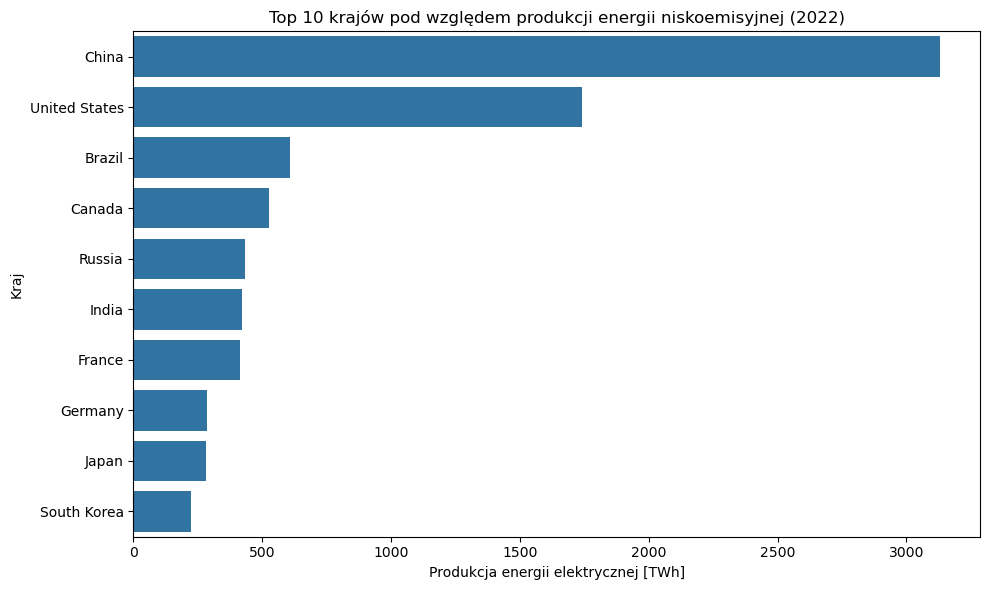

In [198]:
# wybranie ostaniego roku dostępnego w zbiorze danych
latest_year = df_3['year'].max()

# wyodrębnienie danych dla ostatniego roku dostępnego w zbiorze danych
df_2022 = df_3[df_3['year'] == latest_year]

# wyświetlenie 10 krajów o najniższej emisji CO2

top10_low_carbon = (
    df_3[df_3['year'] == latest_year]
    .dropna(subset=['low_carbon_electricity'])
    .nlargest(10, 'low_carbon_electricity')
)

# wykres

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_low_carbon,
    x='low_carbon_electricity',
    y='country'
)

plt.title(
    f'Top 10 krajów pod względem produkcji energii niskoemisyjnej ({latest_year})'
)
plt.xlabel('Produkcja energii elektrycznej [TWh]')
plt.ylabel('Kraj')

plt.tight_layout()
plt.show()

W 2022 roku największą produkcję energii elektrycznej ze źródeł niskoemisyjnych odnotowano w Chinach, które wyraźnie przewyższały pozostałe analizowane kraje. Drugie miejsce zajmowały Stany Zjednoczone, natomiast kolejne pozycje zajmowały m.in. Brazylia, Kanada, Rosja i Indie.

Ranking przedstawia wartości bezwzględne, dlatego nie określa udziału źródeł niskoemisyjnych w całkowitej produkcji energii elektrycznej danego kraju.

#### Zmiany produkcji energii niskoemisyjnej w czasie

W celu oceny zmian zachodzących w sektorze energetycznym przeanalizowano produkcję energii elektrycznej ze źródeł niskoemisyjnych w wybranych krajach w latach 2000–2022.

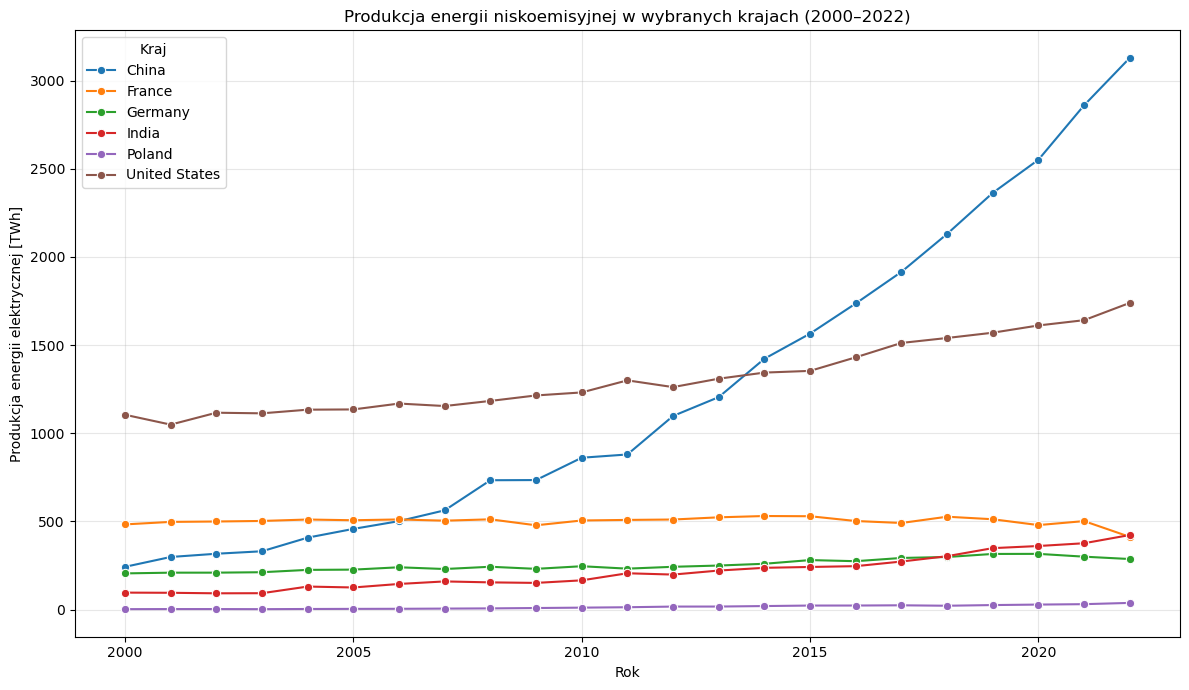

In [199]:
selected_countries = [
    'China',
    'United States',
    'India',
    'Germany',
    'France',
    'Poland'
]

low_carbon_trends = df_3[df_3['country'].isin(selected_countries)]

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=low_carbon_trends,
    x='year',
    y='low_carbon_electricity',
    hue='country',
    marker='o'
)

plt.title('Produkcja energii niskoemisyjnej w wybranych krajach (2000–2022)')
plt.xlabel('Rok')
plt.ylabel('Produkcja energii elektrycznej [TWh]')
plt.legend(title='Kraj')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##### 6.3 Produkcja energii hydroelektrycznej

Energia hydroelektryczna stanowi jedno z najważniejszych odnawialnych źródeł energii elektrycznej. Jej produkcja opiera się na wykorzystaniu energii przepływającej lub spadającej wody, a jej znaczenie w poszczególnych krajach zależy między innymi od uwarunkowań geograficznych, dostępności zasobów wodnych oraz stopnia rozwoju infrastruktury hydrotechnicznej.

W poniższej analizie wykorzystano zmienną hydro_electricity, opisującą wielkość produkcji energii hydroelektrycznej. Analizą objęto dane z ostatniego roku dostępnego w zbiorze, pomijając obserwacje, dla których nie odnotowano wartości tej zmiennej. Następnie wyodrębniono 10 krajów o najwyższym poziomie produkcji i przedstawiono wyniki na wykresie słupkowym. Pozwala to porównać poszczególne państwa oraz wskazać te, które osiągają najwyższe wartości produkcji energii hydroelektrycznej.

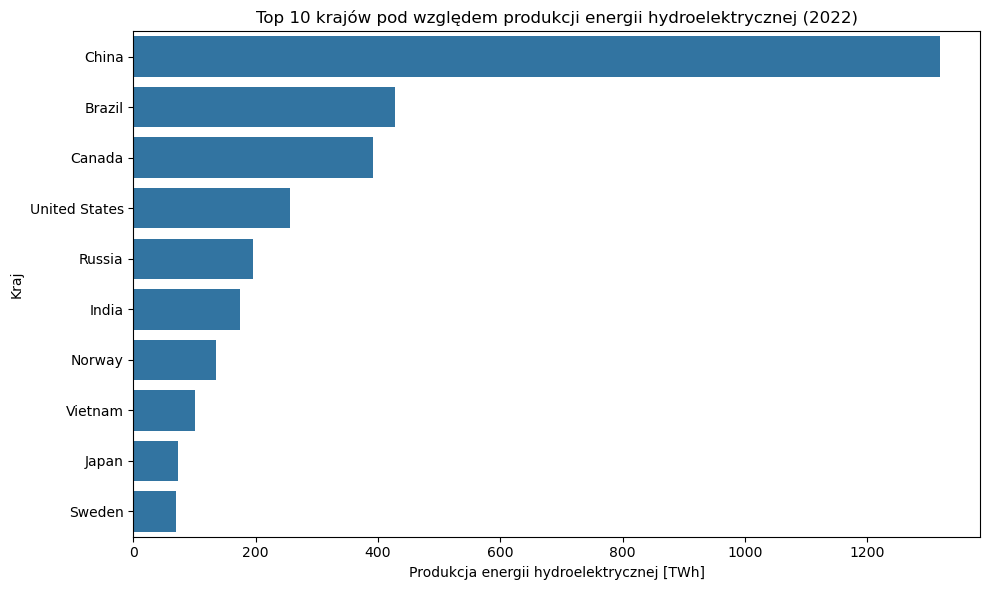

In [200]:

# wyświetlenie 10 krajów z najwyższą wartością w hydro_electricity

top10_hydro = (
    df_3[df_3['year'] == latest_year]
    .dropna(subset=['hydro_electricity'])
    .nlargest(10, 'hydro_electricity')
)

# wykres słupkowy

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_hydro,
    x='hydro_electricity',
    y='country'
)

plt.title(
    f'Top 10 krajów pod względem produkcji energii hydroelektrycznej ({latest_year})'
)
plt.xlabel('Produkcja energii hydroelektrycznej [TWh]')
plt.ylabel('Kraj')
 
plt.tight_layout()
plt.show()

Na podstawie wykresu można określić, które kraje odgrywają największą rolę w światowej produkcji energii hydroelektrycznej. Zestawienie umożliwia również ocenę różnic w poziomie produkcji pomiędzy liderami a pozostałymi państwami z pierwszej dziesiątki.

## 7. Analiza zużycia energii ze źródeł odnawialnych

Ze względu na pochodzenie źródła energii można podzielić na nieodnawialne, takie jak węgiel, ropa naftowa, gaz ziemny i uran, oraz odnawialne, do których zalicza się między innymi energię słoneczną, wiatrową, wodną i geotermalną.

W ostatnich latach coraz większą uwagę poświęca się rozwojowi odnawialnych źródeł energii, które mogą przyczyniać się do ograniczenia emisji gazów cieplarnianych oraz zmniejszenia zależności od paliw kopalnych. Znaczenie poszczególnych źródeł energii różni się jednak między kontynentami oraz samymi krajami i zależy m.in. od dostępności surowców naturalnych, warunków geograficznych, poziomu rozwoju technologicznego oraz prowadzonej polityki energetycznej.

W niniejszym rozdziale skoncentrowano się na odnawialnych źródłach energii (OZE). W celu porównania ich wykorzystania oraz określenia, które z nich mają największy udział w zużyciu energii odnawialnej w poszczególnych regionach świata, przeanalizowano strukturę zużycia OZE na sześciu kontynentach w 2022 roku. Uwzględniono pięć kategorii: energię wodną, wiatrową i słoneczną, biopaliwa oraz pozostałe odnawialne źródła energii.

Wyniki przedstawiono w formie wykresów kołowych, które obrazują procentowy udział poszczególnych źródeł w całkowitym zużyciu energii odnawialnej na każdym kontynencie. Takie zestawienie umożliwia wskazanie dominujących źródeł OZE oraz porównanie struktury ich wykorzystania w poszczególnych regionach świata.

In [201]:
#==================================================================================================
# Analiza struktury zużycia energii odnawialnej na poszczególnych kontynentach w 2022 roku
#==================================================================================================

# utworzenie zbioru danych do analiz dla kontynentów

continents = [
    'Africa',
    'Asia',
    'Europe',
    'North America',
    'South America',
    'Oceania'
]

df_continents = df[df['country'].isin(continents)]
df_continents = df_continents[df_continents['year'] >= 2000]
df_continents

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
245,Africa,2000,NaN,818952374.0,NaN,NaN,0.000,0.000,0.000,2.686,...,0.000,0.001,786.364,0.460,0.519,0.281,0.230,0.634,0.055,0.016
246,Africa,2001,NaN,839464127.0,NaN,NaN,0.000,0.000,0.000,2.585,...,0.000,0.001,136.798,0.702,1.221,0.548,0.460,1.454,0.105,0.037
247,Africa,2002,NaN,860611762.0,NaN,NaN,0.491,0.570,0.491,2.556,...,0.004,0.001,6.739,0.074,1.295,0.500,0.430,1.504,0.093,0.039
248,Africa,2003,NaN,882349569.0,NaN,10.272,0.050,0.613,0.541,2.244,...,0.004,0.002,20.744,0.259,1.553,0.691,0.610,1.760,0.126,0.044
249,Africa,2004,NaN,904781595.0,NaN,17.630,0.095,0.704,0.637,2.420,...,0.004,0.002,43.443,0.661,2.214,0.862,0.780,2.447,0.151,0.059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18052,South America,2018,NaN,424740741.0,NaN,14.015,33.613,643.812,273.453,138.414,...,0.897,0.378,15.867,20.898,158.480,141.380,60.050,373.122,5.192,2.230
18053,South America,2019,NaN,428318218.0,NaN,9.723,26.589,700.511,300.042,136.184,...,1.326,0.581,21.151,32.812,191.292,167.913,71.920,446.612,6.213,2.730
18054,South America,2020,NaN,431530105.0,NaN,-9.513,-28.544,629.151,271.498,146.085,...,1.850,0.872,9.592,17.579,208.871,182.791,78.880,484.025,6.805,3.215
18055,South America,2021,NaN,434254167.0,NaN,0.015,0.041,625.299,271.539,148.162,...,2.599,1.186,25.652,52.619,261.490,227.217,98.670,602.160,8.044,3.719


In [202]:
# zdefiniowanie źródeł odnawialnych (OZE)

renewable_sources = [
    'hydro_consumption',
    'wind_consumption',
    'solar_consumption',
    'biofuel_consumption',
    'other_renewable_consumption'
]

# pobranie danych dotyczących zużycia poszczególnych źródeł OZE w 2022 roku dla kontynentów

renewable_2022 = (
    df_continents[
        df_continents['year'] == 2022
    ]
    .set_index('country')[renewable_sources]
)

renewable_2022


,hydro_consumption,wind_consumption,solar_consumption,biofuel_consumption,other_renewable_consumption
country,,,,,
Africa,408.593,62.294,47.402,1.122,23.925
Asia,5207.568,2365.340,1944.585,219.470,1142.141
Europe,1819.005,1365.527,607.998,239.864,693.408
North America,1811.065,1301.692,608.449,463.559,273.241
Oceania,113.116,89.993,101.990,1.394,33.991
South America,1858.034,293.241,130.086,273.246,218.916


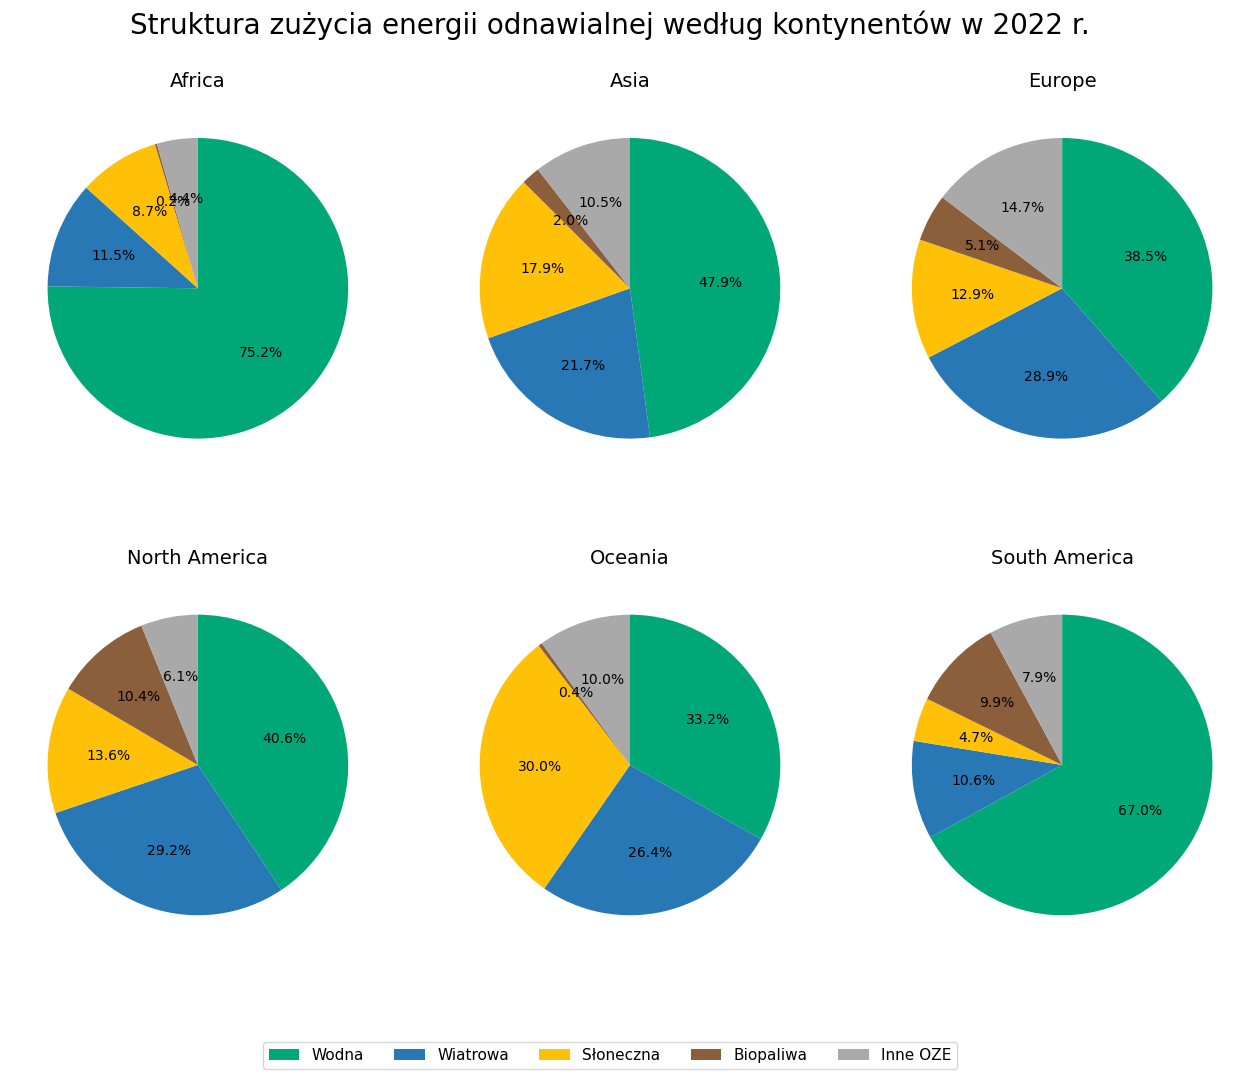

In [203]:
# Wykresy
# Struktura zużycia energii odnawialnej według kontynentów w 2022 roku

fig, axes = plt.subplots(2, 3, figsize=(16, 11))

labels = [
    'Wodna',
    'Wiatrowa',
    'Słoneczna',
    'Biopaliwa',
    'Inne OZE'
]

colors = [
    '#00A878',  # Hydro – intensywna zieleń
    '#2878B5',  # Wiatr – niebieski
    '#FFC107',  # Słońce – żółty
    '#8B5E3C',  # Biopaliwa – brązowy
    '#A9A9A9'   # Inne OZE – szary
]

for ax, continent in zip(axes.flat, renewable_2022.index):

    values = renewable_2022.loc[continent]

    ax.pie(
        values,
        labels=None,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        textprops={'fontsize': 10}
)

    ax.set_title(
        continent,
        fontsize=14,
        pad=10
    )

# Wspólny tytuł
fig.suptitle(
    'Struktura zużycia energii odnawialnej według kontynentów w 2022 r.',
    fontsize=20,
    y=0.98
)

# Wspólna legenda
fig.legend(
    labels,
    loc='lower center',
    ncol=5,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.01)
)

plt.subplots_adjust(
    top=0.90,
    bottom=0.12,
    hspace=0.25,
    wspace=0.15
)

plt.show()


Na podstawie wykresów można porównać znaczenie poszczególnych źródeł energii odnawialnej w strukturze ich zużycia na różnych kontynentach. Szczególną uwagę warto zwrócić na udział energii wodnej i wiatrowej oraz na rosnące znaczenie energii słonecznej. Widoczne różnice mogą wynikać między innymi z warunków naturalnych, dostępności zasobów oraz stopnia rozwoju poszczególnych technologii. Należy przy tym pamiętać, że wykresy przedstawiają strukturę zużycia OZE, a nie udział odnawialnych źródeł w całkowitym zużyciu energii.

W celu uzupełnienia analizy przekrojowej zbadano zmiany całkowitego zużycia energii odnawialnej na poszczególnych kontynentach w latach 2000–2022. Analiza szeregu czasowego pozwala ocenić, czy wykorzystanie odnawialnych źródeł energii wzrastało, oraz porównać tempo i skalę tych zmian między regionami świata.

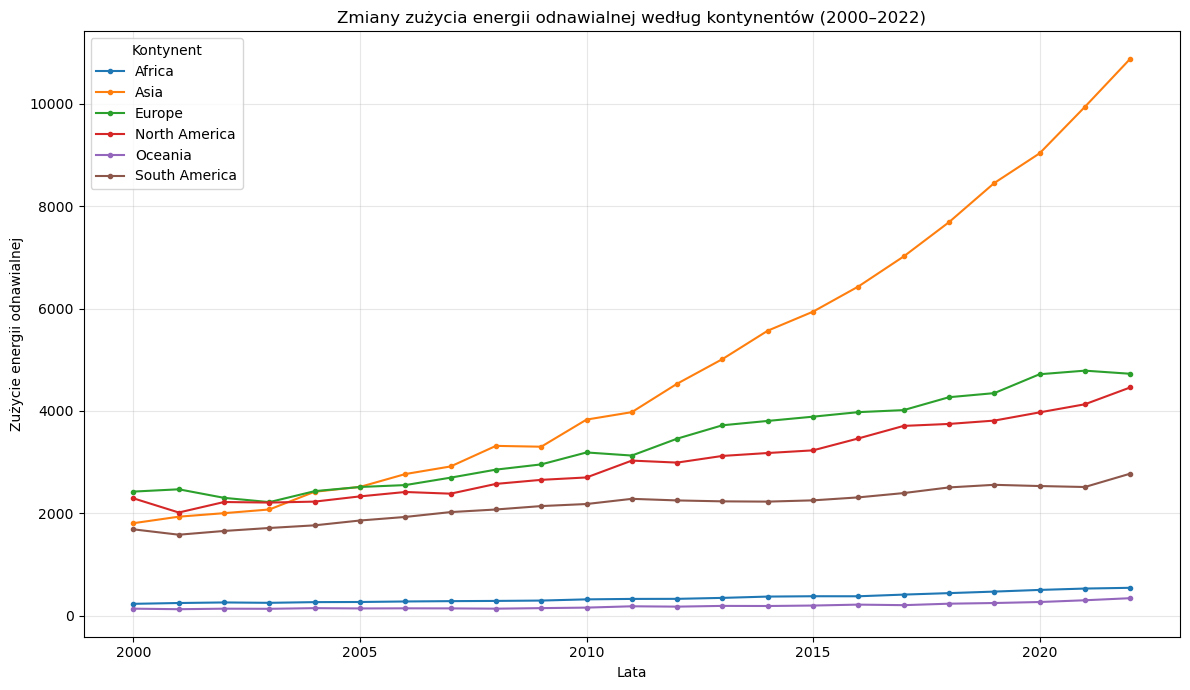

In [204]:
# Obliczenie całkowitego zużycia OZE dla każdego kontynentu i roku

df_trend = df_continents.copy()

df_trend['total_renewables'] = (
    df_trend[renewable_sources].sum(axis=1, min_count=1)
)

trend_data = (
    df_trend
    .pivot(
        index='year',
        columns='country',
        values='total_renewables'
    )
)

plt.figure(figsize=(12, 7))

for continent in trend_data.columns:
    plt.plot(
        trend_data.index,
        trend_data[continent],
        marker='o',
        markersize=3,
        label=continent
    )

plt.title('Zmiany zużycia energii odnawialnej według kontynentów (2000–2022)')
plt.xlabel('Lata')
plt.ylabel('Zużycie energii odnawialnej')
plt.legend(title='Kontynent')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Analiza zmian w czasie pozwala ocenić, jak kształtowało się zużycie energii odnawialnej na poszczególnych kontynentach. Należy zwrócić uwagę na ogólny kierunek zmian, okresy szybszego wzrostu oraz różnice między regionami. Wzrost zużycia OZE może wskazywać na zwiększające się wykorzystanie tych źródeł w gospodarce, jednak sam w sobie nie przesądza o wzroście ich udziału w całkowitym zużyciu energii. 

In [205]:
#======================================================================
# Porównanie udziału OZE w zużyciu energii w 2000 i 2022 roku
#======================================================================

renewables_share_comparison = (
    df_continents[
        df_continents['year'].isin([2000, 2022])
    ]
    .pivot(
        index='country',
        columns='year',
        values='renewables_share_energy'
    )
)

# Zmiana udziału OZE w punktach procentowych
renewables_share_comparison['change_pp'] = (
    renewables_share_comparison[2022]
    - renewables_share_comparison[2000]
)

# Zaokrąglenie wyników
renewables_share_comparison = renewables_share_comparison.round(2)

# Wyświetlenie wyników w kolejności od największej do najmniejszej zmiany p.proc.
renewables_share_comparison = renewables_share_comparison.sort_values('change_pp', ascending=False)

renewables_share_comparison

year,2000,2022,change_pp
country,,,
Oceania,8.83,17.98,9.14
Europe,7.80,16.56,8.76
Asia,4.90,12.04,7.14
North America,7.06,13.28,6.22
South America,33.57,37.78,4.21
Africa,7.21,9.66,2.45


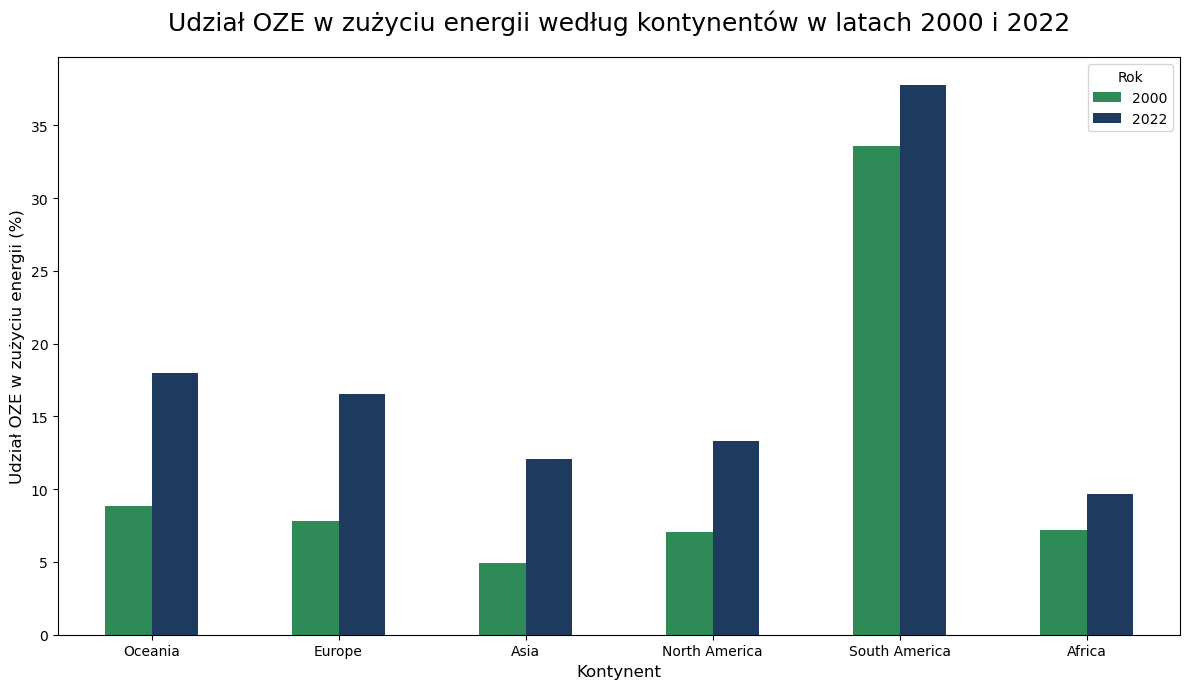

In [206]:
# Wykres: Udział OZE w zużyciu energii według kontynentów – 2000 i 2022

renewables_share_comparison[[2000, 2022]].plot(
    kind='bar',
    figsize=(12, 7),
    color=['#2E8B57', '#1F3A5F']
)

plt.title(
    'Udział OZE w zużyciu energii według kontynentów w latach 2000 i 2022',
    fontsize=18,
    pad=20
)

plt.xlabel('Kontynent', fontsize=12)
plt.ylabel('Udział OZE w zużyciu energii (%)', fontsize=12)

plt.xticks(rotation=0)
plt.legend(title='Rok')

plt.tight_layout()
plt.show()

W 2022 r. w porównaniu do 2000 r. udział OZE w zużyciu energii wzrósł na wszystkich analizowanych kontynentach. Największy wzrost nastąpił w Oceanii – z poziomu 8,83% do 17,98%. Wysoki wzrost wystąpił również w Europie i Azji. Największy udział OZE w obu analizowanych latach miała Ameryka Południowa, natomiast w 2022 roku najniższy udział odnotowano w Afryce.

#### Stopień wykorzystania OZE w wybranych krajach

Stopień wykorzystania energii z odnawialnych źródeł

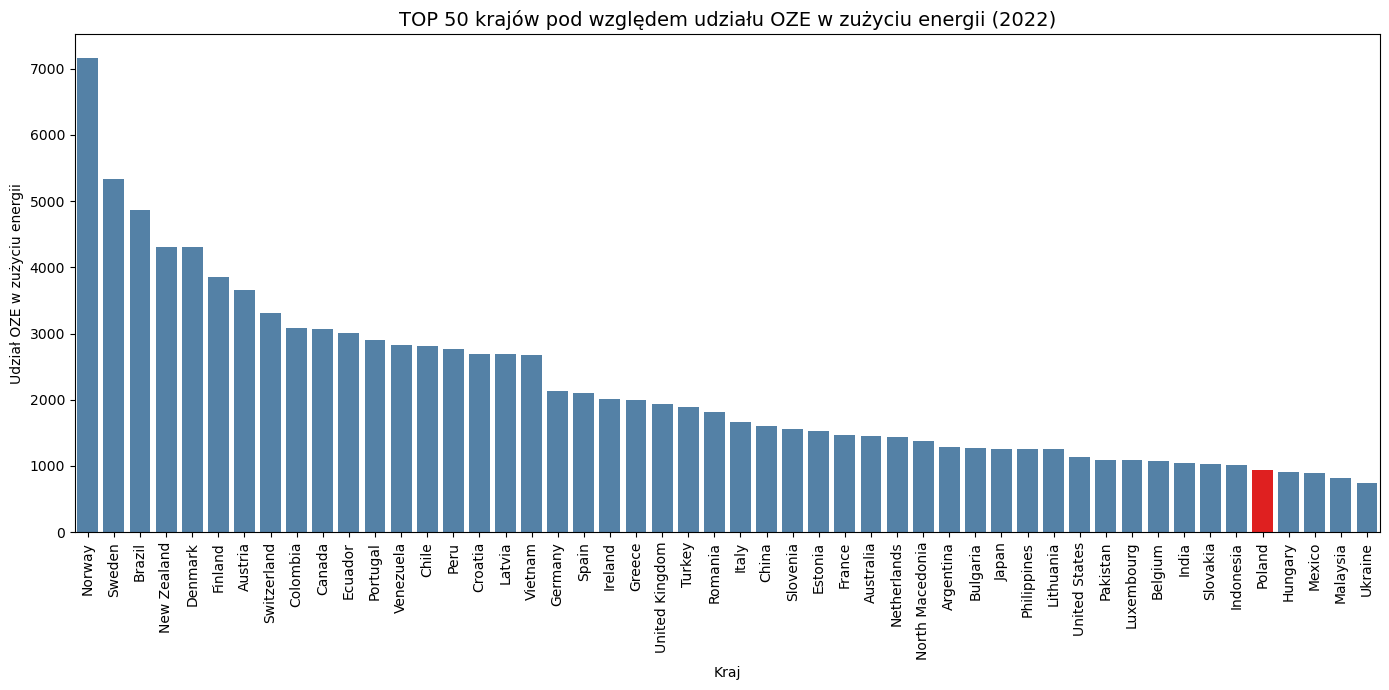

In [207]:
latest_year = df['year'].max()

latest_year = df_2['year'].max()

renewable_df = (
    df_2.loc[
        df_2['year'] == latest_year,
        ['country', 'renewables_share_energy']
    ]
    .dropna()
    .copy()
)

# Przeliczenie na procenty
renewable_df['renewables_share_energy'] *= 100

# TOP 30 krajów
top50_renewables = (
    renewable_df
    .nlargest(50, 'renewables_share_energy')
    .sort_values('renewables_share_energy', ascending=False)
    .copy()
)

# Polska na czerwono
colors = [
    'red' if country == 'Poland' else 'steelblue'
    for country in top50_renewables['country']
]

plt.figure(figsize=(14, 7))

sns.barplot(
    data=top50_renewables,
    x='country',
    y='renewables_share_energy',
    hue='country',
    palette=dict(zip(top50_renewables['country'], colors)),
    order=top50_renewables['country'],
    legend=False
)

plt.title(
    f'TOP 50 krajów pod względem udziału OZE w zużyciu energii ({latest_year})',
    fontsize=14
)

plt.xlabel('Kraj')
plt.ylabel('Udział OZE w zużyciu energii')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Energia słoneczna
W celu określenia krajów o największym znaczeniu energii słonecznej w strukturze zużycia energii przeanalizowano udział energii słonecznej w całkowitym zużyciu energii w 2022 roku. Na podstawie tego wskaźnika wyznaczono kraje charakteryzujące się najwyższymi wartościami.

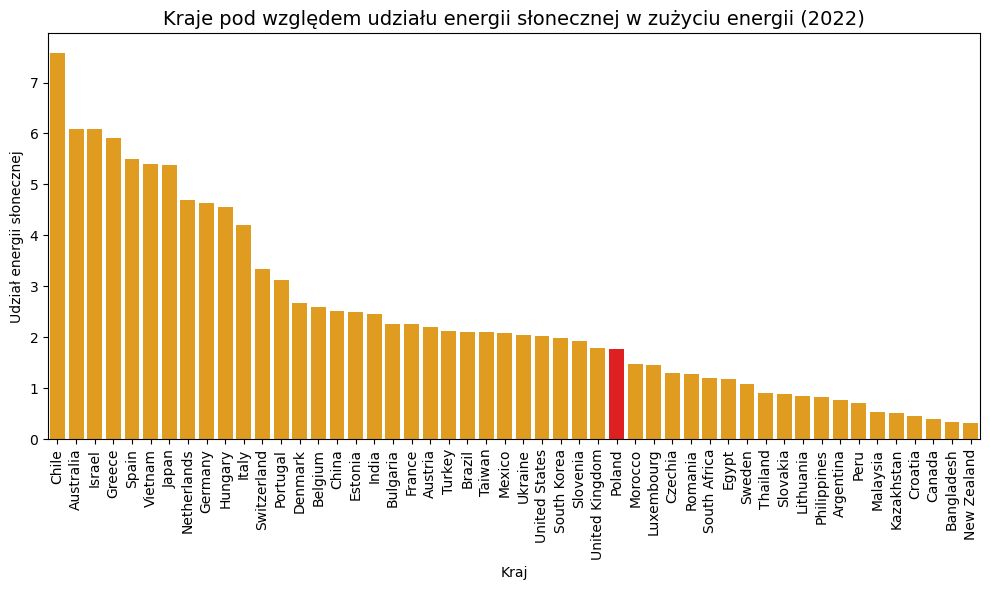

In [208]:
# wyodrębnienie danych dla ostatniego roku dostępnego w zbiorze danych
df_2022 = df_2[df_2['year'] == latest_year]

top_countries = (
    df_2022
    .nlargest(50, 'solar_share_energy')
    .copy()
)

# Kolor pomarańczowy dla wszystkich krajów, czerwony dla Polski
colors = [
    'red' if country == 'Poland' else 'orange'
    for country in top_countries['country']
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_countries,
    x='country',
    y='solar_share_energy',
    hue='country',
    palette=dict(zip(top_countries['country'], colors)),
    legend=False
)

plt.title(
    'Kraje pod względem udziału energii słonecznej w zużyciu energii (2022)',
    fontsize=14
)

plt.xlabel('Kraj')
plt.ylabel('Udział energii słonecznej')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

#### Energia wiatrowa

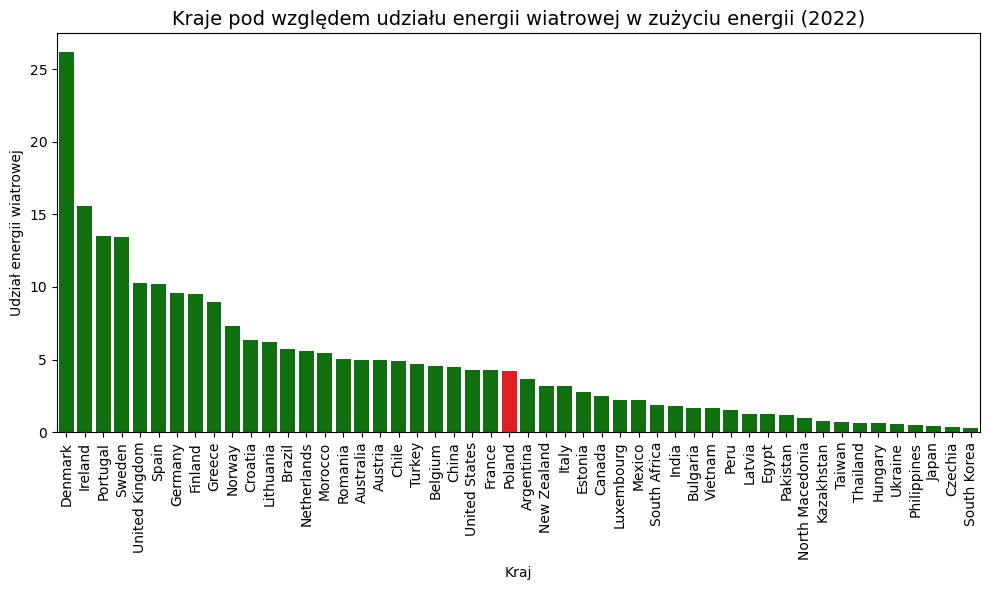

In [209]:
top_countries = (
    df_2022
    .nlargest(50, 'wind_share_energy')
    .sort_values(by='wind_share_energy', ascending=False)
    .copy()
)

# Kolor pomarańczowy dla wszystkich krajów, czerwony dla Polski
colors = [
    'red' if country == 'Poland' else 'green'
    for country in top_countries['country']
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_countries,
    x='country',
    y='wind_share_energy',
    hue='country',
    palette=dict(zip(top_countries['country'], colors)),
    legend=False
)

plt.title(
    'Kraje pod względem udziału energii wiatrowej w zużyciu energii (2022)',
    fontsize=14
)

plt.xlabel('Kraj')
plt.ylabel('Udział energii wiatrowej')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

#### Biopaliwa (biofuel_consumption)

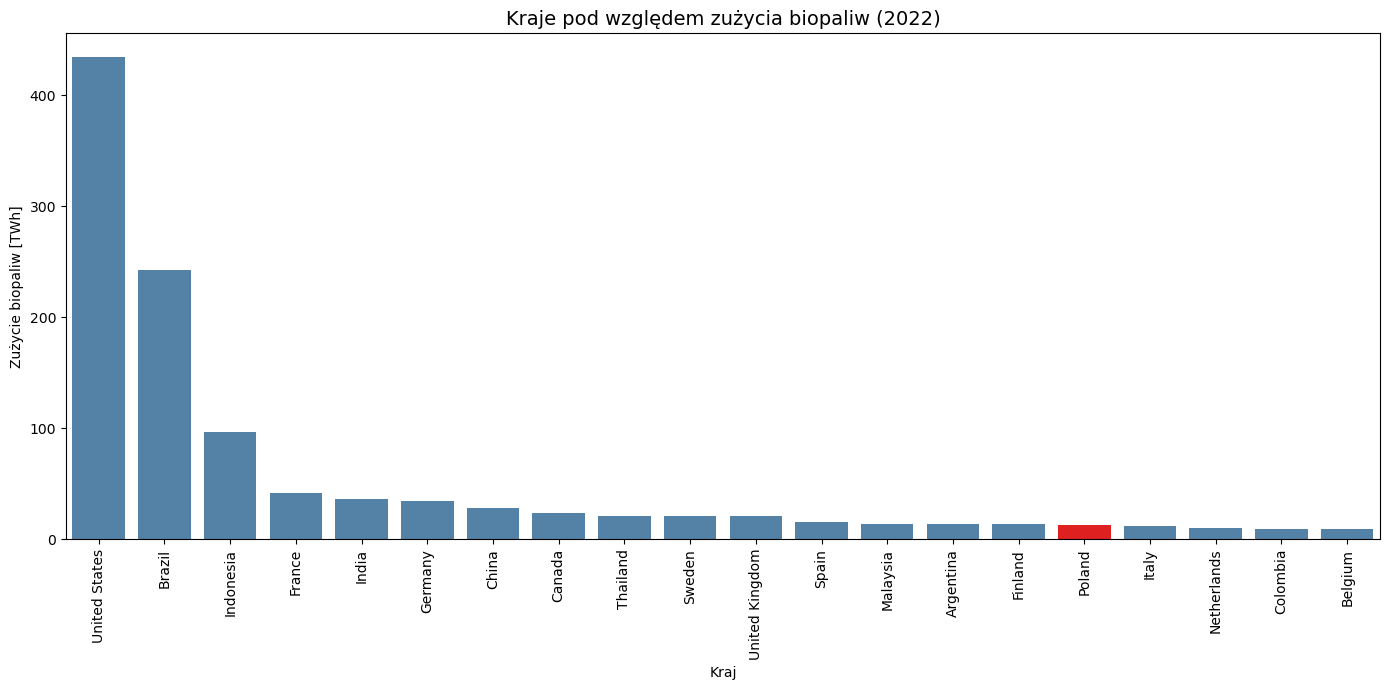

In [210]:
# TOP 20 krajów pod względem zużycia biopaliw w 2022 roku
top_countries_biofuel = (
    df_2022[
        ['country', 'biofuel_consumption']
    ]
    .dropna(subset=['biofuel_consumption'])
    .nlargest(20, 'biofuel_consumption')
    .sort_values('biofuel_consumption', ascending=False)
    .copy()
)

# Kolor czerwony dla Polski, niebieski dla pozostałych krajów
colors = [
    'red' if country == 'Poland' else 'steelblue'
    for country in top_countries_biofuel['country']
]

# Wykres kolumnowy
plt.figure(figsize=(14, 7))

sns.barplot(
    data=top_countries_biofuel,
    x='country',
    y='biofuel_consumption',
    hue='country',
    palette=dict(zip(top_countries_biofuel['country'], colors)),
    order=top_countries_biofuel['country'],
    legend=False
)

plt.title(
    'Kraje pod względem zużycia biopaliw (2022)',
    fontsize=14
)

plt.xlabel('Kraj')
plt.ylabel('Zużycie biopaliw [TWh]')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 8. Analiza zużycia energii pierwotnej

##### 8.1 Zużycie energii pierwotnej w wg kontynentów w 2022 r.

Na potrzeby analizy porównawczej wybrano wyłącznie rekordy, których nazwy odpowiadają podstawowym nazwom kontynentów, tj. Afryce, Azji, Europie, Ameryce Północnej, Ameryce Południowej oraz Oceanii. Nie uwzględniono rekordów zawierających dodatkowe oznaczenia w nawiasach, takich jak „Africa (EI)” czy „Africa (Ember)”. Wynika to z faktu, że w zbiorze występują różne agregaty regionalne związane z poszczególnymi źródłami danych i metodami ich opracowania. Ich połączenie z podstawowymi agregatami mogłoby prowadzić do wielokrotnego uwzględnienia podobnych obszarów geograficznych oraz utrudniać jednoznaczną interpretację wyników.

W analizie nie dokonywano również samodzielnego sumowania danych dotyczących poszczególnych państw w celu wyznaczenia wartości dla kontynentów. Wykorzystano gotowe agregaty kontynentalne udostępnione w zbiorze danych. Pozwala to zachować sposób agregacji zastosowany przez autorów źródłowego zbioru oraz uniknąć potencjalnych rozbieżności wynikających z samodzielnego sumowania danych dla państw i regionów.

In [211]:
# Sprawdzenie brakujących wartości dla analizowanej zmiennej
df_continents[
    df_continents['year'].isin([2000, 2022])
][['country', 'year', 'primary_energy_consumption']].isna().sum()

country                       0
year                          0
primary_energy_consumption    0
dtype: int64

Jak zmieniło się zużycie energii pierwotnej ('primary_energy_consumption') na poszczególnych kontynentach pomiędzy 2000 a 2022 rokiem?

In [212]:
#===============================================================
# Porównanie zużycia energii pierwotnej w 2000 i 2022 roku
#===============================================================

energy_comparison = (
    df_continents[
        df_continents['year'].isin([2000, 2022])
    ]
    .pivot(
        index='country',
        columns='year',
        values='primary_energy_consumption'
    )
)
energy_comparison


year,2000,2022
country,,
Africa,3195.780,5626.826
Asia,36846.555,90365.438
Europe,31077.365,28543.871
North America,32465.496,33580.207
Oceania,1534.817,1894.211
South America,5021.526,7340.591


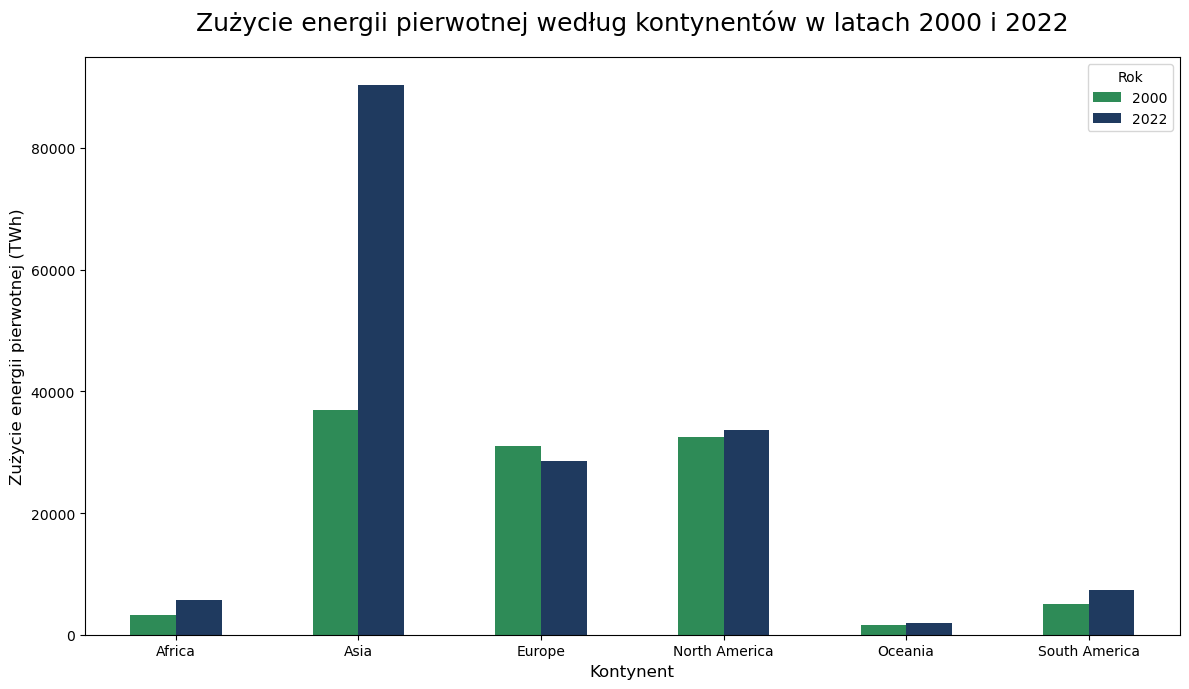

In [213]:
# wykres kolumnowy
# Zużycie energii pierwotnej według kontynentów w latach 2000 i 2022

energy_comparison[[2000, 2022]].plot(
    kind='bar',
    figsize=(12, 7),
    color=['#2E8B57', '#1F3A5F']
)

plt.title(
    'Zużycie energii pierwotnej według kontynentów w latach 2000 i 2022',
    fontsize=18,
    pad=20
)

plt.xlabel('Kontynent', fontsize=12)
plt.ylabel('Zużycie energii pierwotnej (TWh)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Rok')
plt.tight_layout()
plt.show()

W celu porównania zmian w zużyciu energii pierwotnej zestawiono wartości dla 2000 i 2022 roku. Zastosowanie dwóch punktów czasowych pozwala określić kierunek oraz skalę zmian zachodzących w poszczególnych regionach świata.

Największy procentowy wzrost zużycia energii pierwotnej w analizowanym okresie odnotowano w Azji (145,25%), a najmniejszy w Ameryce Północnej (3,43%). W Europie, jako jedynym kontynencie wśród rozpatrywanych, zanotowano spadek (o 8,15%) zużycia energii pierwotnej w 2022 r. w porównaniu z 2000 r. 

##### 8.2 Zużycie energii pierwotnej w wybranych krajach w 2022 r.

W pierwszym etapie analizy wyznaczono 10 krajów o najwyższym całkowitym zużyciu energii pierwotnej w ostatnim roku dostępnym w zbiorze danych (2022). Do porównania wykorzystano zmienną "primary_energy_consumption", wyrażającą całkowite zużycie energii pierwotnej w danym kraju, mierzone w TWh. 

Analiza pozwala wskazać kraje charakteryzujące się największym zapotrzebowaniem na energię w ujęciu całkowitym, jednak nie uwzględnia różnic w liczbie ludności poszczególnych państw.

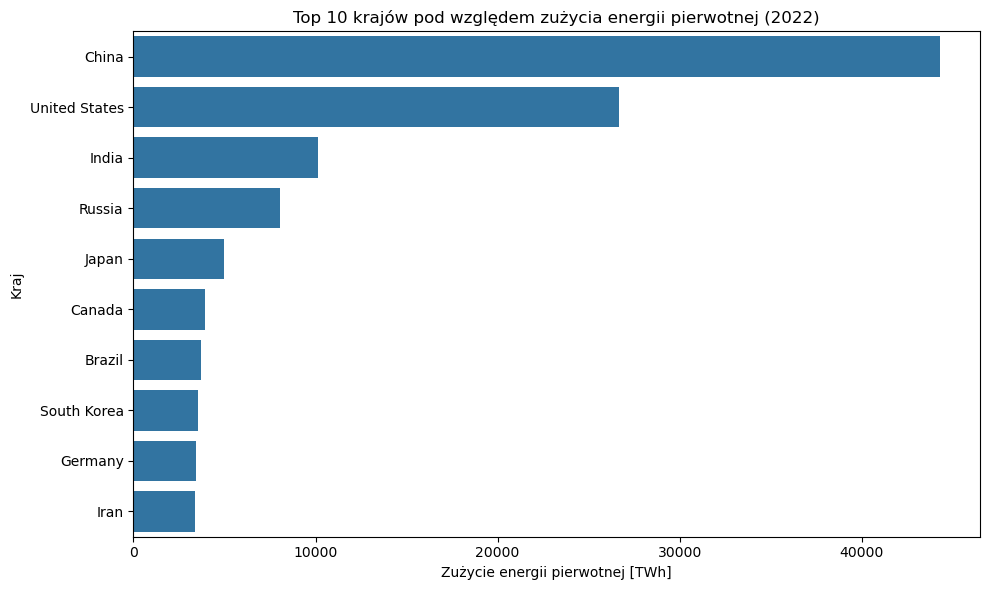

In [214]:
# ========================================================================
#         Analiza zużycia energii pierwotnej w krajach (TOP 10)     
# ========================================================================

# wyświetlenie TOP 10 krajów pod względem zużycia energii pierwotnej w ostatnim roku dostępnych danych
top10_energy = (df_2022.nlargest(10, 'primary_energy_consumption'))

# wykres słupkowy przedstawiający TOP 10 krajów pod względem zużycia energii pierwotnej w ostatnim roku dostępnych danych

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_energy,
    x='primary_energy_consumption',
    y='country'
)

plt.title(
    f'Top 10 krajów pod względem zużycia energii pierwotnej ({latest_year})'
)
plt.xlabel('Zużycie energii pierwotnej [TWh]')
plt.ylabel('Kraj')

plt.tight_layout()
plt.show()

W 2022 r. największe zużycie energii pierwotnej odnotowano w Chinach, które wyraźnie przewyższały pozostałe analizowane kraje. Drugie miejsce zajmowały Stany Zjednoczone, a kolejne Indie i Rosja. Wyniki wskazują na dużą koncentrację światowego zużycia energii w największych gospodarkach.

Na drugim końcu rankingu, wśród 5 państw o najmniejszym całkowitym zużyciu energii pierwotnej, znalazły się Burundi, Czad, Sudan Południowy, Montenegro i Kongo. Poza Montenegro (Europa), pozostałe cztery kraje, położone są w Afryce.

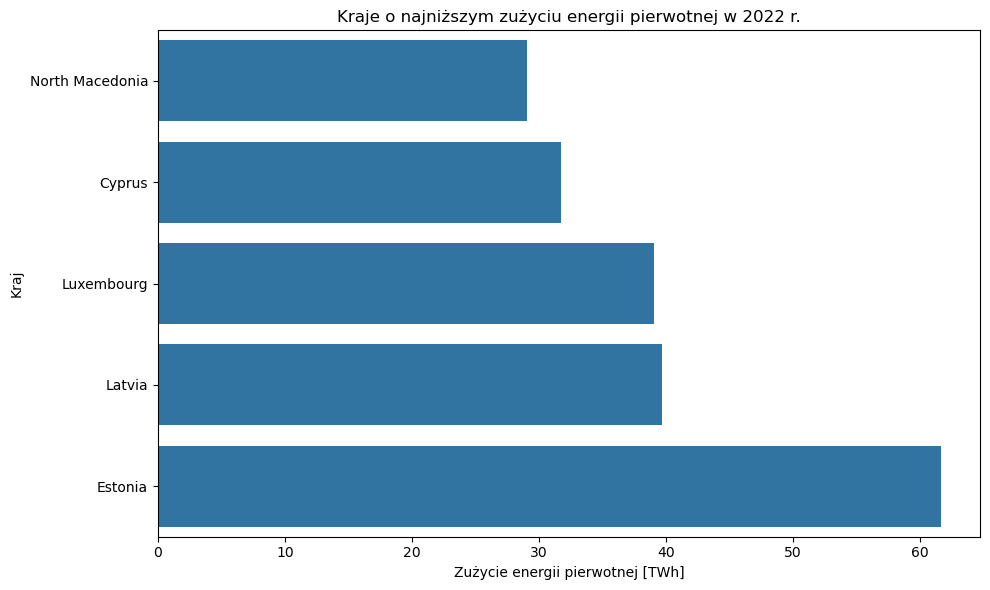

In [215]:
# ========================================================================
#         Analiza zużycia energii pierwotnej w krajach  (BOTTOM 10)    
# ========================================================================


# wyświetlenie BOTTOM 10 krajów pod względem zużycia energii pierwotnej w ostatnim roku dostępnych danych
bottom5_energy = (df_2022.nsmallest(5, 'primary_energy_consumption'))

# wykres słupkowy przedstawiający BOTTOM 5 krajów pod względem zużycia energii pierwotnej w ostatnim roku dostępnych danych

plt.figure(figsize=(10, 6))

sns.barplot(
    data=bottom5_energy,
    x='primary_energy_consumption',
    y='country'
)

plt.title(
    f'Kraje o najniższym zużyciu energii pierwotnej w {latest_year} r.'
)
plt.xlabel('Zużycie energii pierwotnej [TWh]')
plt.ylabel('Kraj')

plt.tight_layout()
plt.show()

Polska pod względem zużycia energii pierwotnej plasuje się na 26. miejscu - za Tajwanem i Wietnamem, wyprzedzając Egipt, Argentynę i Pakistan.

In [216]:
# Ranking wszystkich krajów według zużycia energii pierwotnej
ranking_energy = (
    df_2022
    .sort_values('primary_energy_consumption', ascending=False)
    .reset_index(drop=True)
)

# Pozycja Polski w rankingu
poland_position = ranking_energy.index[
    ranking_energy['country'] == 'Poland'
][0] + 1

print(f"Polska zajmuje {poland_position}. miejsce pod względem zużycia energii pierwotnej.")


# kraje wokół Polski w rankingu 
ranking_around_poland = ranking_energy.iloc[
    max(0, poland_position - 3): poland_position + 3
]

print(
    ranking_around_poland[
        ['country', 'primary_energy_consumption']
    ]
)


Polska zajmuje 26. miejsce pod względem zużycia energii pierwotnej.
      country  primary_energy_consumption
23     Taiwan                    1328.629
24    Vietnam                    1274.762
25     Poland                    1198.322
26      Egypt                    1105.468
27  Argentina                    1000.973
28   Pakistan                    1000.547


Całkowite zużycie energii jest silnie związane z wielkością kraju i jego populacją. Dlatego, ze względu na znaczne różnice w liczebności populacji poszczególnych krajów, samo porównanie całkowitego zużycia energii nie pozwala ocenić poziomu zużycia przypadającego na pojedynczego mieszkańca. 

W związku z tym, by umożliwić bardziej porównywalną ocenę wykorzystano zmienną "energy_per_capita", przedstawiającą zużycie energii pierwotnej w przeliczeniu na jednego mieszkańca w poszczególnych państwach.

##### 8.3 Zużycie energii w przeliczeniu na 1 mieszkańca w 2022 r.

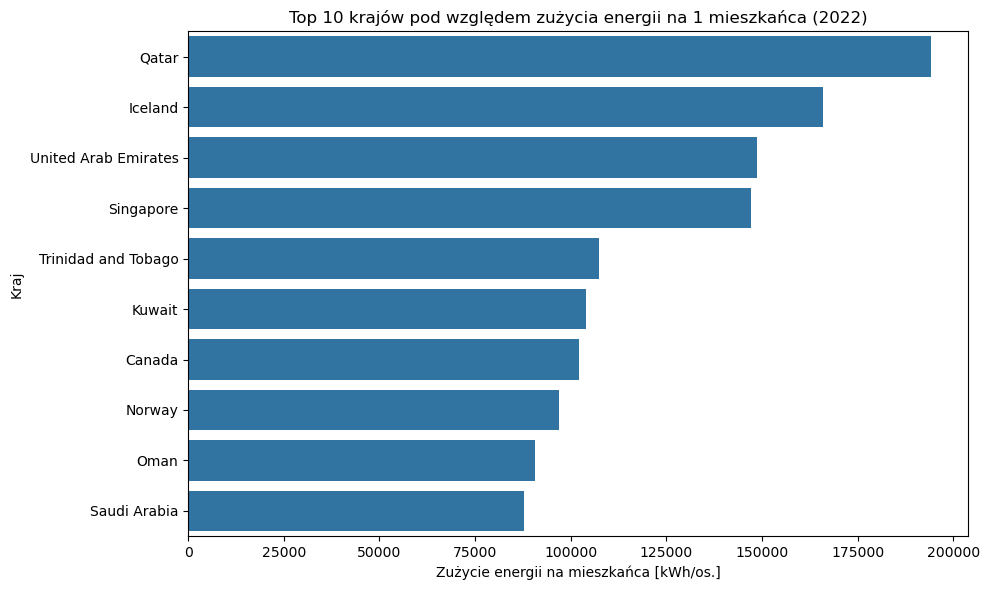

In [217]:
# ========================================================================
#         Analiza zużycia energii na mieszkańca w krajach   (TOP 10)
# ========================================================================

top10_per_capita = (df_2022
    .dropna(subset=['energy_per_capita'])
    .nlargest(10, 'energy_per_capita')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_per_capita,
    x='energy_per_capita',
    y='country'
)

plt.title(
    f'Top 10 krajów pod względem zużycia energii na 1 mieszkańca ({latest_year})'
)
plt.xlabel('Zużycie energii na mieszkańca [kWh/os.]')
plt.ylabel('Kraj')

plt.tight_layout()
plt.show()

Ranking zużycia energii w przeliczeniu na mieszkańca znacząco różni się od rankingu całkowitego zużycia energii. W 2022 r. najwyższe wartości zużycia energii na mieszkańca odnotowano w Katarze, a następnie w Islandii i Bahrajnie. Wyniki te pokazują, że wielkość populacji ma istotny wpływ na całkowite zużycie energii, dlatego analiza wartości w przeliczeniu na mieszkańca stanowi ważne uzupełnienie porównań między krajami. Pozwala ona na bardziej miarodajną ocenę poziomu zużycia energii, niezależną od różnic w liczbie ludności poszczególnych państw.

W celu bardziej szczegółowego zbadania zależności pomiędzy wielkością populacji a całkowitym zużyciem energii pierwotnej przygotowano wykres, na którym przedstawiono liczbę mieszkańców w odniesieniu do całkowitego zużycia energii pierwotnej. Zastosowano skalę logarytmiczną na obu osiach, co pozwala na czytelne przedstawienie danych charakteryzujących się dużym zróżnicowaniem wartości pomiędzy krajami. Wielkość bąbelków odpowiada zużyciu energii pierwotnej w przeliczeniu na 1 mieszkańca. Dla łatwiejszego zidentyfikowania Polski na tle pozostałych krajów zaznaczono ją kolorem czerwonym. Dodatkowo podpisano pięć krajów o najwyższym zużyciu energii na mieszkańca, kraj o najniższym zużyciu energii na 1 mieszkańca oraz kraj o największej populacji.

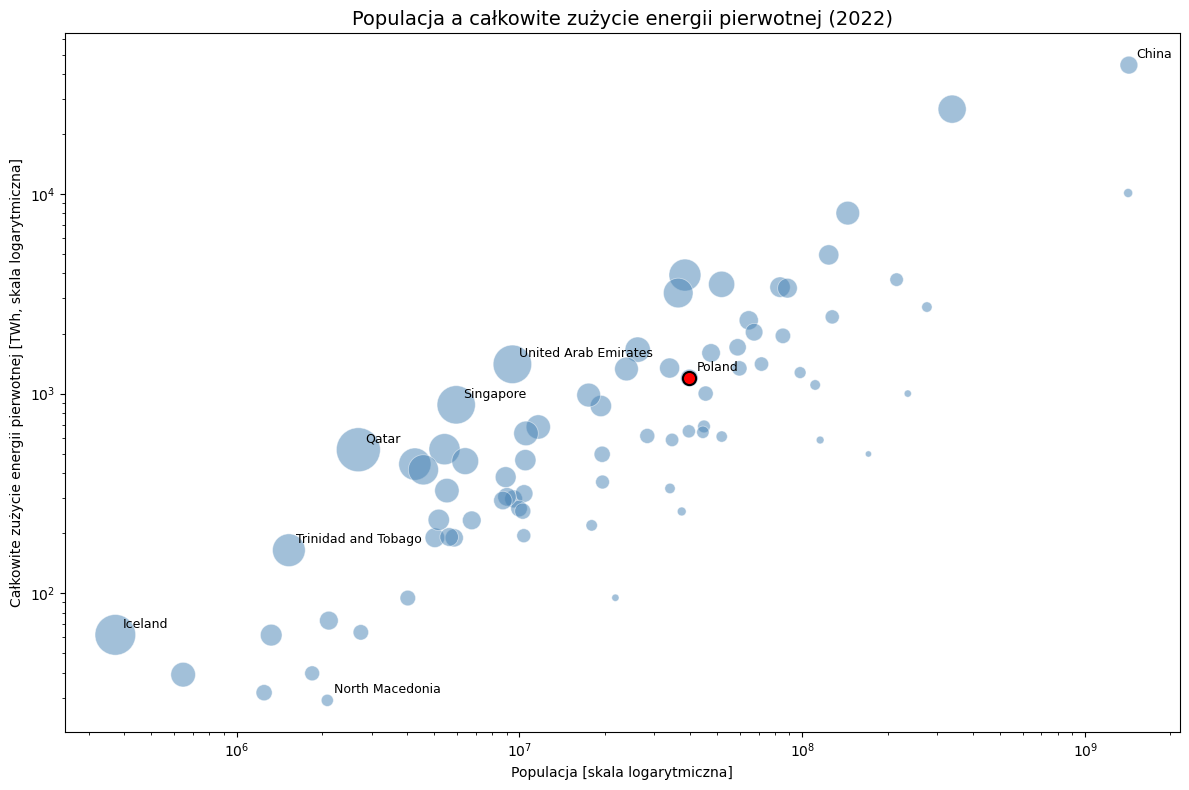

In [218]:
plt.figure(figsize=(12, 8))

# Wszystkie kraje
sns.scatterplot(
    data=df_2022,
    x='population',
    y='primary_energy_consumption',
    size='energy_per_capita',
    sizes=(20, 1000),
    alpha=0.5,
    color='steelblue',
    legend=False
)

# Polska
poland = df_2022[df_2022['country'] == 'Poland']

sns.scatterplot(
    data=poland,
    x='population',
    y='primary_energy_consumption',
    size='energy_per_capita',
    sizes=(90, 1000),
    color='red',
    edgecolor='black',
    linewidth=1.5,
    legend=False
)


# Skala logarytmiczna
plt.xscale('log')
plt.yscale('log')

# 5 krajów z najwyższym zużyciem energii na mieszkańca
top5 = df_2022.nlargest(5, 'energy_per_capita')

# Kraj o największej populacji
largest_population = df_2022.nlargest(1, 'population')

# Kraj o najmniejszym całkowitym zużyciu energii
lowest_energy = df_2022.nsmallest(1, 'primary_energy_consumption')

# Polska
poland = df_2022[df_2022['country'] == 'Poland']

# Połączenie wszystkich krajów, które chcemy podpisać
labels = pd.concat([
    top5,
    poland,
    largest_population,
    lowest_energy
]).drop_duplicates(subset='country')

# Dodanie nazw państw
for _, row in labels.iterrows():
    plt.annotate(
        row['country'],
        (row['population'], row['primary_energy_consumption']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

# Opis wykresu

plt.title(
    f'Populacja a całkowite zużycie energii pierwotnej ({latest_year})',
    fontsize=14
)

plt.xlabel(
    'Populacja [skala logarytmiczna]'
)

plt.ylabel(
    'Całkowite zużycie energii pierwotnej [TWh, skala logarytmiczna]'
)


plt.tight_layout()
plt.show()



Na wykresie widoczna jest wyraźna dodatnia zależność pomiędzy wielkością populacji a całkowitym zużyciem energii pierwotnej. Kraje o większej liczbie mieszkańców na ogół charakteryzują się również wyższym całkowitym zużyciem energii. Najbardziej widocznym przykładem są Chiny, które ze względu na bardzo dużą populację znajdują się także wysoko pod względem całkowitego zużycia energii.

Jednocześnie wykres pokazuje, że sama wielkość populacji nie wyjaśnia w pełni różnic w zużyciu energii. Bąbelki różnią się wielkością, co wskazuje na znaczne różnice w zużyciu energii przypadającym na jednego mieszkańca. Oznacza to, że kraje o podobnej liczbie mieszkańców mogą charakteryzować się odmiennym poziomem całkowitego zużycia energii.

Polska znajduje się w środkowej części analizowanego zestawienia pod względem zarówno liczby ludności, jak i całkowitego zużycia energii. Jej pozycja różni się jednak od krajów o najwyższym zużyciu energii na mieszkańca, co dodatkowo pokazuje znaczenie uwzględniania wskaźników per capita w porównaniach międzynarodowych.

## 9. Zużycie energii a PKB

W kolejnym etapie analizy zbadano zależność pomiędzy poziomem rozwoju gospodarczego a zużyciem energii w przeliczeniu na 1 mieszkańca. 
Jako miarę poziomu rozwoju gospodarczego przyjęto PKB na mieszkańca (gdp_per_capita), natomiast poziom konsumpcji energii przedstawiono za pomocą zużycia energii pierwotnej na mieszkańca (energy_per_capita). 
Obliczenia przeprowadzono dla ostatniego dostępnego roku w zbiorze danych, tj. 2022.

W pierwszej kolejności, z racji niewystępowania w zbiorze danych zmiennej PKB/mieszkańca, należało wyznaczyć taką wartość.

In [219]:
# sprawdzenie, czy w zbiorze danych istnieje kolumna 'gdp_per_capita'
'gdp_per_capita' in df.columns

False

In [220]:
#========================================================================
# Wyznaczenie PKB per capita dla każdego kraju w 2022 roku
#========================================================================

df_2022['gdp_per_capita'] = round(df_2022['gdp'] / df_2022['population'],2)

# sprawdzenie poprawności obliczeń
df_2022[['country', 'year', 'gdp', 'population', 'gdp_per_capita']].head()

/var/folders/c9/ygg1ptk506n7_w3bl2_7q5840000gn/T/ipykernel_64384/824903801.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2022['gdp_per_capita'] = round(df_2022['gdp'] / df_2022['population'],2)


,country,year,gdp,population,gdp_per_capita
710,Algeria,2022,NaN,44903228.0,NaN
875,Angola,2022,NaN,35588996.0,NaN
1082,Argentina,2022,NaN,45510324.0,NaN
1634,Australia,2022,NaN,26177410.0,NaN
1799,Austria,2022,NaN,8939617.0,NaN


Dla zobrazowania zależnośći pomiędzy wskazanymi zmiennymi w 2022 r. ("gdp_per_capita", "energy_per_capita") przygotowano wykres rozrzutu.
Na podstawie wykresu i dodatkowych obliczeń, sprawdzono czy wyższy poziom PKB na mieszkańca wiąże się z większym zużyciem energii przypadającym na jednego mieszkańca.

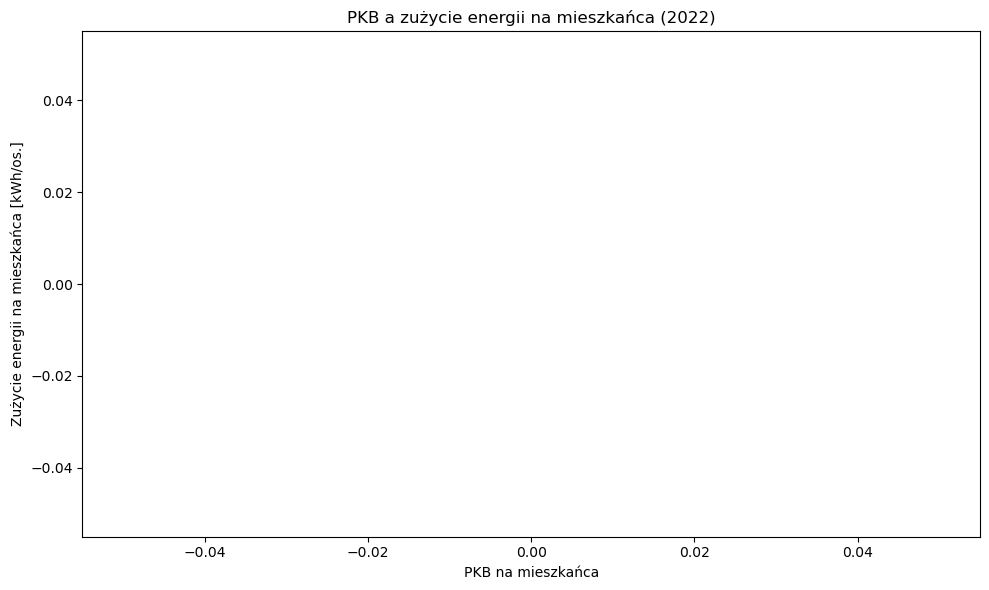

In [221]:
df_2022.dropna(subset=['gdp_per_capita', 'energy_per_capita'])

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_2022,
    x='gdp_per_capita',
    y='energy_per_capita',
    alpha=0.7
)

plt.title('PKB a zużycie energii na mieszkańca (2022)')
plt.xlabel('PKB na mieszkańca')
plt.ylabel('Zużycie energii na mieszkańca [kWh/os.]')

plt.tight_layout()
plt.show()

In [222]:
#=======================================================================================================
# Wyznaczenie współczynnika korelacji 
# między PKB/mieszk. a zużyciem energii na mieszkańca w 2022 roku
#=======================================================================================================

correlation = df_2022[
    ['gdp_per_capita', 'energy_per_capita']
].corr()

correlation

,gdp_per_capita,energy_per_capita
gdp_per_capita,NaN,NaN
energy_per_capita,NaN,1.0


Analiza wykresu rozrzutu wskazuje na dodatnią zależność między PKB na mieszkańca a zużyciem energii przypadającym na 1 mieszkańca. Macierz korelacji potwierdza tę zależność - współczynnik korelacji wyniósł r= 0.7996.

Jednocześnie zależność ta nie jest jednoznaczna - dla krajów o podobnym poziomie PKB/mieszkańca występują różnice w poziomie zużycia energii na 1 mieszkańca. Może to wynikać m.in. ze struktury gospodarki, poziomu uprzemysłowienia, warunków klimatycznych, dostępności surowców energetycznych oraz stosowanych technologii.

W przypadku państw o niższym PKB/mieszkańca punkty są dość skupione, natomiast przy wyższym PKB/mieszkańca występuje znacznie większe zróżnicowanie zużycia energii przypadającego na 1 mieszkańca.

Na wykresie można zaobserwować też kilka obserwacji odstających, szczególnie państwa o bardzo wysokim zużyciu energii w stosunku do swojego PKB.

Na podstawie przeprowadzonych analiz, wynika że poziom rozwoju gospodarczego jest jednym z czynników związanych ze zużyciem energii na mieszkańca, jednak nie jest jedynym czynnikiem determinującym jego poziom.
Korelacja nie oznacza również związku przyczynowo-skutkowego.

Dla zbadania, jakie inne zmienne spośród wybranych są skorelowane i w jakim stopniu z PKB na mieszkańca, opracowano macierz korelacji dla wybranych zmiennych w 2022 r. W ten sposób określono kierunek oraz siłę zależności liniowych między różnymi zmiennymi.

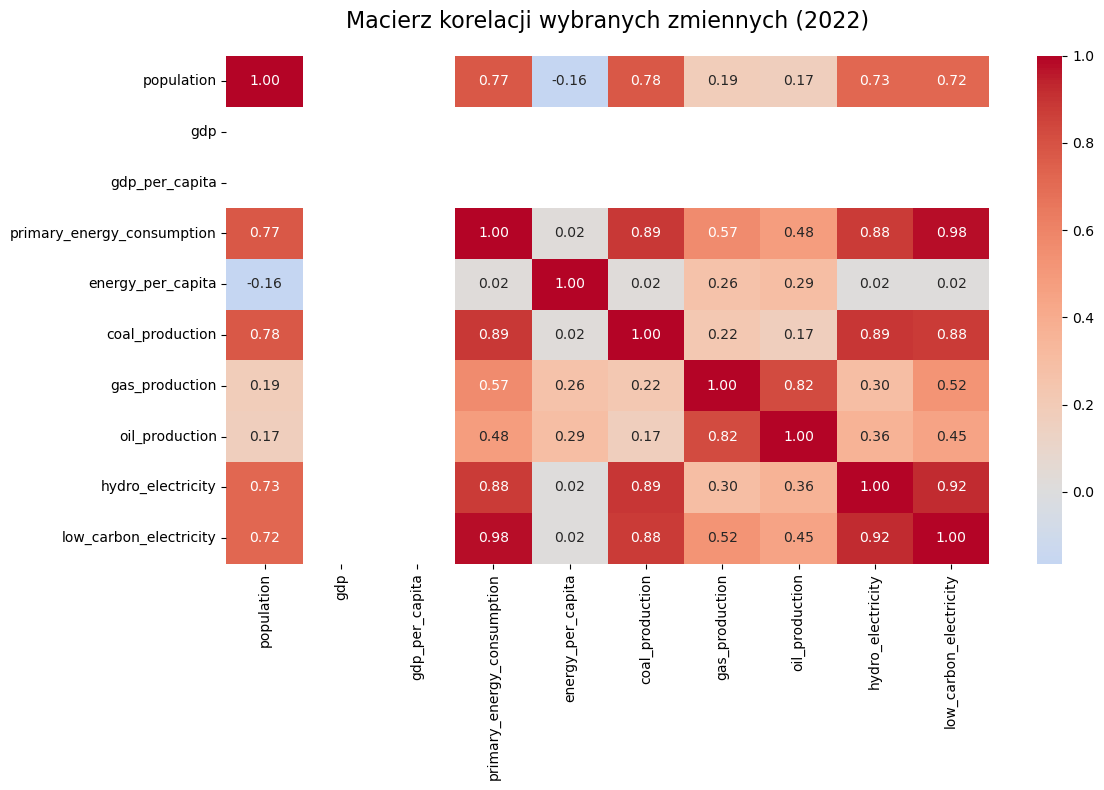

In [223]:
#=======================================================================================================
# Wyznaczenie macierzy korelacji dla wybranych zmiennych w 2022 roku
#=======================================================================================================

correlation_columns = [
    'population',
    'gdp',
    'gdp_per_capita',
    'primary_energy_consumption',
    'energy_per_capita',
    'coal_production',
    'gas_production',
    'oil_production',
    'hydro_electricity',
    'low_carbon_electricity'
]

corr_matrix = df_2022[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Macierz korelacji wybranych zmiennych (2022)', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

Między PKB a zużyciem energii pierwotnej mamy korelację 0,95, co oznacza, że w badanym zbiorze państwa z wyższym PKB mają zazwyczaj zdecydowanie większe całkowite zużycie energii. Trzeba jednak uważać z interpretacją: korelacja nie oznacza, że wzrost PKB bezpośrednio powoduje wzrost zużycia energii. Obie zmienne mogą być związane np. z wielkością gospodarki, populacją, poziomem uprzemysłowienia itd.

PKB na mieszkańca i zużycie energii na mieszkańca mają korelację 0,80, więc również występuje bardzo silna dodatnia zależność. To jest szczególnie interesujące, ponieważ pokazuje, że zależność widoczna na pierwszym wykresie ma również sens po uwzględnieniu liczby mieszkańców. Natomiast PKB na mieszkańca i całkowite zużycie energii mają tylko korelację około 0,03. To pokazuje, że przy analizie wartości całkowitych bardzo duże znaczenie ma liczba ludności.

Korelacja między PKB a zużyciem energii pierwotnej wynosi 0,95, natomiast między PKB na mieszkańca a zużyciem energii na mieszkańca - 0,80. Silne korelacje występują również między zużyciem energii pierwotnej a produkcją węgla (0,89) oraz hydroelektrowniami (0,88). Oznacza to, że poziom rozwoju gospodarczego i struktura produkcji energii są silnie powiązane z poziomem zużycia energii. Należy jednak pamiętać, że korelacja opisuje współzależność i sama w sobie nie dowodzi związku przyczynowo-skutkowego.

# Podsumowanie

***Do opracowania ostatecznej wersji***

wkład Oli

Przeprowadzona analiza pozwoliła określić najważniejsze zależności i tendencje związane ze zużyciem energii na świecie w latach 2000–2022.

Najważniejsze wnioski z analizy są następujące:

* Największe całkowite zużycie energii odnotowano w największych gospodarkach świata, przede wszystkim w Chinach, Stanach Zjednoczonych i Indiach. Wskazuje to na silną koncentrację światowego zużycia energii w krajach o dużej populacji i wysokiej aktywności gospodarczej.
* Zużycie energii na mieszkańca daje inny obraz niż wartości całkowite. Wysokie wartości tego wskaźnika występują również w niewielkich, zamożnych państwach, dlatego analiza per capita jest istotnym uzupełnieniem porównań między krajami.
* Zużycie energii zmieniało się w czasie w różny sposób w poszczególnych państwach. Szczególnie dynamiczne zmiany widoczne są w przypadku Chin, podczas gdy w części rozwiniętych gospodarek obserwowane są bardziej stabilne lub spadkowe tendencje.
* Polska charakteryzuje się znacznie niższym całkowitym zużyciem energii niż największe gospodarki świata. Jej poziom zużycia należy jednak interpretować z uwzględnieniem wielkości populacji oraz struktury gospodarki.
* Pomiędzy PKB na mieszkańca a zużyciem energii na mieszkańca występuje silna dodatnia korelacja, której wartość w analizie dla 2022 roku wynosi około 0,80. Oznacza to, że wyższemu poziomowi PKB na mieszkańca zazwyczaj towarzyszy wyższe zużycie energii na mieszkańca.
* Źródła niskoemisyjne stanowią istotny element transformacji energetycznej. Analiza ich wykorzystania pozwala zauważyć zmiany w strukturze światowego systemu energetycznego w badanym okresie.

Ograniczenia analizy:

* Na wyniki wpływa dostępność danych dla poszczególnych państw i lat. Zbiór zawiera również agregaty regionalne oraz grupy państw, dlatego w rankingach państwowych wykorzystano wyłącznie jednostki posiadające kod ISO.
* Korelacja pomiędzy PKB a zużyciem energii nie oznacza związku przyczynowo-skutkowego. Na zużycie energii wpływa wiele innych czynników, których nie uwzględniono w niniejszej analizie.

Odpowiedź na główne pytanie badawcze:

Analiza pokazuje, że zużycie energii jest silnie związane zarówno z wielkością gospodarki i populacji, jak i z poziomem rozwoju gospodarczego. Jednocześnie porównanie wartości całkowitych i per capita pokazuje, że do pełnej oceny sytuacji energetycznej państw konieczne jest wykorzystanie kilku uzupełniających się wskaźników

CZĘŚĆ MICHAŁA